# Periodicity Search with Lasair


## Get TNS data


In [4]:
import numpy as np
import pandas as pd

# tns_filename = 'tables/tns_public_objects_20250615.csv'
tns_filename = 'tables/tns_public_objects_until_20250916.csv'
tns = pd.read_csv(tns_filename, header=0)
tns = tns[np.logical_and(tns['redshift'] <= 0.05, tns['declination'] > -60)]

sn_typeids = [4, 5, 6, 7, 9, 106]  # SN Ib, Ic, Ib/c, Ic-BL, Ibn, Ia-CSM
tns_ibc = tns[np.isin(tns['typeid'], sn_typeids)]

# exclude_names = ['2018ebt', '2018yn']  # seem like CV?
# tns_ibc = tns_ibc[~tns_ibc['name'].isin(exclude_names)]

tns_ibc


,objid,name_prefix,name,ra,declination,redshift,typeid,type,reporting_groupid,reporting_group,...,discoverymag,discmagfilter,filter,reporters,time_received,internal_names,Discovery_ADS_bibcode,Class_ADS_bibcodes,creationdate,lastmodified
223,186785,SN,2025vaw,259.986968,24.931626,0.019000,7.0,SN Ic-BL,18.0,ATLAS,...,16.9000,73.0,wide,"J. Tonry, L. Denneau, H. Weiland, R. Siverd (I...",2025-08-23 01:01:14,"ATLAS25kew, ZTF25abkwytp, GOTO25gqc, PS25hlu",2025TNSTR3331....1T,2025TNSCR3383....1M,2025-08-23 01:01:16,2025-09-14 13:25:13
356,187431,SN,2025vzq,349.769999,-8.477634,0.007452,5.0,SN Ic,59.0,GOTO,...,19.2200,120.0,L,"D. O'Neill, K. Ackley, M. Dyer, J. Lyman, K. U...",2025-08-28 13:31:03,"GOTO25glk, ATLAS25kqi, ZTF25abmsmeg, , PS25hld",2025TNSTR3412....1O,2025TNSCR3449....1W,2025-08-28 13:31:05,2025-09-11 20:42:45
539,187120,SN,2025vnr,275.383605,25.338430,0.024834,5.0,SN Ic,48.0,ZTF,...,19.4786,111.0,r,"Jesper Sollerman (SU), Christoffer Fremling (C...",2025-08-27 05:49:17,ZTF25abmhftu,2025TNSTR3397....1S,2025TNSCR3626....1D,2025-08-27 05:49:18,2025-09-08 18:16:28
560,185286,SN,2025svz,227.294001,-6.530128,0.023900,7.0,SN Ic-BL,18.0,ATLAS,...,18.7610,73.0,wide,"J. Tonry, L. Denneau, H. Weiland, R. Siverd (I...",2025-08-01 08:53:36,"ATLAS25irk, GOTO25fru, ZTF25abnzacu",2025TNSTR3022....1T,2025TNSCR3265....1E,2025-08-01 08:53:39,2025-09-08 15:36:29
593,184894,SN,2025shi,342.176185,27.582791,0.031952,9.0,SN Ibn,74.0,ALeRCE,...,20.2915,111.0,r,"F. Forster, F.E. Bauer, G. Pignata, A. Munoz-A...",2025-07-26 19:06:09,"ZTF25abecbib, GOTO25fms, ATLAS25ipf, PS25hie",2025TNSTR2908....1F,"2025TNSCR3056....1D, 2025TNSCR3093....1D",2025-07-26 19:06:15,2025-09-07 17:48:55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171657,11409,SN,2016bau,170.245917,53.173778,0.003856,4.0,SN Ib,0.0,NaN,...,17.8000,1.0,Clear,Ron Arbour,2016-03-14 00:32:20,NaN,2016TNSTR.215....1A,2016TNSCR.224....1B,2016-03-14 00:32:20,2016-03-14 00:32:20
171761,11303,SN,2016aws,154.894230,-1.009060,0.043000,4.0,SN Ib,4.0,Pan-STARRS,...,20.3773,26.0,w,"K. C. Chambers, M. E. Huber, H. Flewelling, E....",2016-03-10 22:54:02,PS16awz,2016TNSTR.197....1C,2016TNSCR.218....1P,2016-03-10 22:54:02,2016-03-10 22:54:02
172105,10958,SN,2016ajo,281.052042,24.158250,0.016000,4.0,SN Ib,10.0,XOSS,...,15.7000,1.0,Clear,"Yi Ding, Wei Gao, Xing Gao",2016-02-22 07:01:50,NaN,2016TNSTR.143....1D,2016TNSCR.233....1T,2016-02-22 07:01:50,2016-02-22 07:01:50
173040,10018,SN,2016P,209.379583,6.097500,0.014600,7.0,SN Ic-BL,12.0,RANSSP,...,16.0000,1.0,Clear,"G. Duszanowicz, M. Zolnowski",2016-01-19 18:31:32,NaN,2016TNSTR..33....1D,2016TNSCR..40....1Z,2016-01-19 16:38:47,2016-01-19 16:38:47


In [5]:
def get_sn_row(name):
    return tns_ibc[tns_ibc['name'] == name].iloc[0]


## Create a library of candidates


In [6]:
import numpy as np
from astropy.time import Time

from periodicity_tools import get_decline_detections, get_decline_detections_fp


EPOCH_AFTER_PEAK = 1000
MIN_DETECTINOS_PER_BAND = 20

candidate_library = []

all_peak_mags = []
selected_peaks = []

for name in tns_ibc['name']:

    # decline_points = get_decline_detections_fp(name, epoch_after_peak=EPOCH_AFTER_PEAK, bin_daily=True)
    decline_points = get_decline_detections(name, epoch_after_peak=EPOCH_AFTER_PEAK)
    
    object_all_band_peaks = []
    object_selected_band_peaks = []

    for fid in [1, 2]:  # g, r, i bands
        
        band_data = [p for p in decline_points if p.get('fid') == fid and 'candid' in p]

        if len(band_data) > 0:
            m_all = np.array([p['magpsf'] for p in band_data])
            object_all_band_peaks.append(np.min(m_all))

        if len(band_data) < MIN_DETECTINOS_PER_BAND:
           continue

        t = np.array([p['jd'] for p in band_data])
        m = np.array([p['magpsf'] for p in band_data])
        e = np.array([p['sigmapsf'] for p in band_data])
        
        object_selected_band_peaks.append(np.min(m))

        days = t - t[0]                  
        sn_row = get_sn_row(name)
        peak_after_disc_days = t[0] - Time(sn_row['discoverydate']).jd

        candidate_library.append({
            'name': name, 
            'days_offset': peak_after_disc_days,
            'fid': fid, 
            'days': days,  # days since peak
            'mags': m, 
            'errs': e
        })

    if len(object_all_band_peaks) > 0:
        all_peak_mags.append(np.min(object_all_band_peaks))

    if len(object_selected_band_peaks) > 0:
        selected_peaks.append(np.min(object_selected_band_peaks))

n_cands = len(candidate_library)
n_unique = len(set(entry['name'] for entry in candidate_library))
print(f"Built candidate library with {n_cands} entries.")
print("Number of unique candidates:", n_unique)
print(f"{n_unique} single-band, {n_cands - n_unique} dual-band entries.")


Built candidate library with 118 entries.
Number of unique candidates: 84
84 single-band, 34 dual-band entries.


Total objects with light curves: 439
Total objects with >20 detections in at least one band: 84


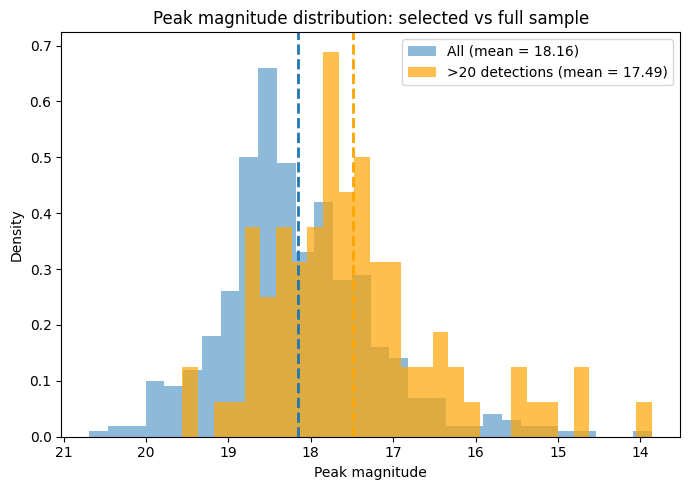

In [90]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.hist(
    all_peak_mags,
    bins=30,
    alpha=0.5,
    density=True,
    color='C0',
    label=f"All (mean = {np.mean(all_peak_mags):.2f})"
)

plt.hist(
    selected_peaks,
    bins=30,
    alpha=0.7,
    density=True,
    color='orange',
    label=f">20 detections (mean = {np.mean(selected_peaks):.2f})"
)

plt.axvline(np.mean(all_peak_mags), linestyle="--", linewidth=2, color='C0')
plt.axvline(np.mean(selected_peaks), linestyle="--", linewidth=2, color='orange')

plt.gca().invert_xaxis()  # brighter magnitudes on the left
plt.xlabel("Peak magnitude")
plt.ylabel("Density")
plt.title("Peak magnitude distribution: selected vs full sample")
plt.legend()
plt.tight_layout()

print("Total objects with light curves:", len(all_peak_mags))
print("Total objects with >20 detections in at least one band:", len(selected_peaks))
plt.savefig("Figures/peak_mag_comparison.pdf", bbox_inches='tight', dpi=300)
plt.show()


### Calculate Global FAP


In [16]:
from collections import defaultdict
from periodicity_tools import MAX_FREQ

p_single_threshold = 1e-4
N_false = 0
Ts = []
M_list = []

use_only_dual_band_targets = False

# Define a more conservative library with only dual bands
bands_per_sn = defaultdict(set)
for entry in candidate_library:
    bands_per_sn[entry["name"]].add(entry["fid"])
dual_band_sne = {
    name for name, bands in bands_per_sn.items()
    if {1, 2}.issubset(bands)
}

for entry in candidate_library:
    
    name = entry["name"]
    if use_only_dual_band_targets and name not in dual_band_sne:
        continue

    days = entry["days"]
    T = days.max() - days.min()
    Ts.append(T)

    f_min = 2 / T
    f_max = MAX_FREQ

    # Effective number of independent frequencies
    M_i = max((f_max - f_min) * T, 0)

    M_list.append(M_i)

    N_false += M_i * p_single_threshold

N_lightcurves = 2 * len(dual_band_sne)

print("Total sample size (light curves):", N_lightcurves)
print("Total expected false alarms in survey:", N_false)
print(f"Fraction of sample: {100 * N_false / N_lightcurves:.3f}%")
print("Min, max T:", np.min(Ts), np.max(Ts))
print("Mean M per light curve:", np.mean(M_list))


Total sample size (light curves): 68
Total expected false alarms in survey: 0.39842690587653806
Fraction of sample: 0.586%
Min, max T: 15.996585600078106 261.664594899863
Mean M per light curve: 33.764992023435404


In [13]:
types = [get_sn_row(name)['typeid'] for name in dual_band_sne]
types_counts = pd.Series(types).value_counts()
print("Type distribution in candidate library:")
print(types_counts)
# SN Ib, Ic, Ib/c, Ic-BL, Ibn, Ia-CSM



Type distribution in candidate library:
4.0      14
5.0      13
7.0       3
106.0     2
9.0       1
6.0       1
Name: count, dtype: int64
Type 106 (Ia-CSM) candidates:
['2022esa', '2020aekp']


## Run survey


In [7]:
from periodicity_tools import analyze_candidate


def run_full_survey(candidate_library):

    grouped_results = {
        "poly3": {},
        "poly4": {},
        "poly5": {},
        "poly6": {},
    }

    methods = ["poly3","poly4","poly5","poly6"]

    for entry in candidate_library:

        name = entry['name']
        fid = entry['fid']
        days = entry['days']
        mags = entry['mags']
        errs = entry['errs']

        res3 = analyze_candidate(name, days, mags, errs, poly_deg=3)
        res4 = analyze_candidate(name, days, mags, errs, poly_deg=4)
        res5 = analyze_candidate(name, days, mags, errs, poly_deg=5)
        res6 = analyze_candidate(name, days, mags, errs, poly_deg=6)

        # Add fid
        for r in [res3, res4, res5, res6]:
            r["fid"] = fid

        # Group by SN name
        for method, res in zip(
            methods,
            [res3, res4, res5, res6]
        ):
            if name not in grouped_results[method]:
                grouped_results[method][name] = []
            grouped_results[method][name].append(res)

    return grouped_results

grouped_results = run_full_survey(candidate_library)


### Find double hits


In [8]:
from periodicity_tools import compute_delta_chi2_curve
from scipy.stats import chi2


SINGLE_FREQ_P = 1e-4

def find_dual_band_hits(grouped_results, candidate_library):
    """
    Search for candidates that show significant periodicity in both bands, with consistent periods.
        Criteria for dual-band hit:
        1. Both bands must have some significant peak p-value < SINGLE_FREQ_P
        2. Both bands must have best amplitude >= MDA (minimal detectable amplitude).
        3. To avoid missing harmonics, the period is chosen based on the stronger Δχ² (out of 2 bands)
             and then we look for a significant peak in the other band within a tolerance of T/P
    """

    methods = ["poly3", "poly4", "poly5", "poly6"]
    double_hits = {method: set() for method in methods}
    updated_grouped = {method: {} for method in methods}

    for method in methods:

        poly_deg = int(method.replace("poly", ""))

        for name, band_results in grouped_results[method].items():

            if len(band_results) < 2:
                continue
            
            if len(band_results) > 2:
                r1, r2, r3 = band_results
            else:
                r1, r2 = band_results

            if not (
                r1["p_value_single_freq"] < SINGLE_FREQ_P and
                r2["p_value_single_freq"] < SINGLE_FREQ_P and
                r1["best_amplitude"] >= r1["mda"] and
                r2["best_amplitude"] >= r2["mda"]
            ):
                continue

            # Choose anchor band (stronger Δχ²)
            if r1["delta_chi2"] >= r2["delta_chi2"]:
                anchor = r1
                other = r2
            else:
                anchor = r2
                other = r1

            # Recompute Δχ² curve for the other band
            entry = next(
                e for e in candidate_library
                if e["name"] == name and e["fid"] == other["fid"]
            )

            # Find significant peak in other band within tolerance of anchor period
            freq, dchi2 = compute_delta_chi2_curve(
                entry["days"],
                entry["mags"],
                entry["errs"],
                poly_deg
            )
            periods = 1 / freq

            sig_threshold = chi2.ppf(1 - SINGLE_FREQ_P, df=2)

            P_anchor = anchor["best_period"]
            period_tol = max(r1['best_period']**2/r1['time_baseline'], r2['best_period']**2/r2['time_baseline'])
            period_tol = min(0.1 * P_anchor, period_tol)  # limit tolerance to 10% of anchor period
            tol_mask = np.abs(periods - P_anchor) < period_tol

            if not np.any(tol_mask):
                continue

            dchi2_masked = dchi2[tol_mask]
            periods_masked = periods[tol_mask]
            local_max = (
                (dchi2_masked[1:-1] > dchi2_masked[:-2]) &
                (dchi2_masked[1:-1] > dchi2_masked[2:])
            )
            peak_vals = dchi2_masked[1:-1][local_max]
            peak_periods = periods_masked[1:-1][local_max]
            
            sig_mask = peak_vals > sig_threshold
            if not np.any(sig_mask):
                continue

            best_idx = np.argmax(peak_vals[sig_mask])
            P_match = peak_periods[sig_mask][best_idx]
            dchi2_match = peak_vals[sig_mask][best_idx]

            updated_other = other.copy()
            updated_other["best_period"] = P_match
            updated_other["best_frequency"] = 1.0 / P_match
            updated_other["delta_chi2"] = dchi2_match
            updated_other["p_value_single_freq"] = 1 - chi2.cdf(dchi2_match, df=2)

            updated_grouped[method][name] = [anchor, updated_other]
            double_hits[method].add(name)

    return double_hits, updated_grouped

double_hits, updated_grouped = find_dual_band_hits(grouped_results, candidate_library)
double_hits


{'poly3': {'2020sgf', '2022esa', '2022jli'},
 'poly4': {'2022esa', '2022jli'},
 'poly5': {'2020sgf', '2022jli'},
 'poly6': {'2020sgf', '2022esa', '2022jli'}}

## Ploting


### Plot lightcurve with fit


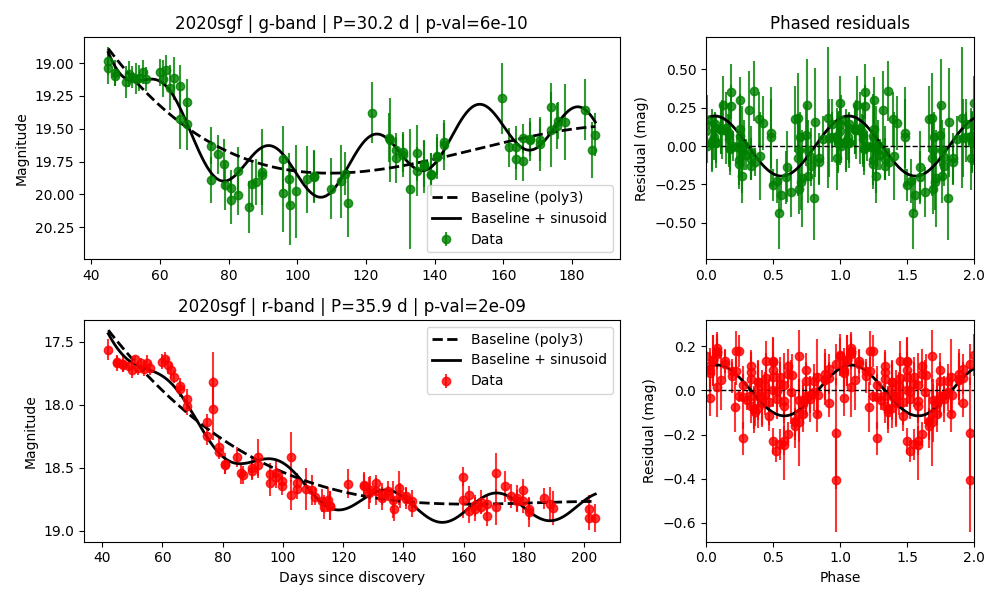

In [86]:
import matplotlib.pyplot as plt

band_colors = {1: 'g', 2: 'r', 3: 'orange'}
band_str = {1: 'g-band', 2: 'r-band', 3: 'i-band'}

def plot_with_phase(grouped_results, candidate_library, sn_name, method="poly3"):

    grouped = grouped_results[method]
    if sn_name not in grouped:
        print(f"{sn_name} not found.")
        return

    band_results = grouped[sn_name]

    _, axes = plt.subplots(2, 2, figsize=(10, 6),
                             gridspec_kw={"width_ratios": [2, 1]})

    for row, res in enumerate(band_results):

        ax_lc = axes[row, 0]
        ax_phase = axes[row, 1]

        fid = res["fid"]
        period = res["best_period"]
        pval = res["p_value_single_freq"]

        entry = next(
            e for e in candidate_library
            if e["name"] == sn_name and e["fid"] == fid
        )

        days = np.asarray(entry["days"])
        mags = np.asarray(entry["mags"])
        errs = np.asarray(entry["errs"])
        days_offset = entry["days_offset"]

        t_grid = np.linspace(days.min(), days.max(), 1000)

        poly_model = res["poly_model"]
        full_model = res["full_model"]

        # Left panel: Light curve + fits
        ax_lc.errorbar(days + days_offset, mags, yerr=errs,
                       fmt='o', label="Data", alpha=0.8,
                       color=band_colors.get(fid, 'k'))

        ax_lc.plot(days_offset + t_grid, poly_model(t_grid),
                   label=f"Baseline ({method})", linewidth=2, color='k', linestyle='--')

        ax_lc.plot(days_offset + t_grid, full_model(t_grid),
                   label="Baseline + sinusoid", linewidth=2, color='k', linestyle='-')

        ax_lc.invert_yaxis()
        ax_lc.set_ylabel("Magnitude")

        pval_str = f"p-val={pval:.1}" if pval > 0 else r"p-val <e-16"
        ax_lc.set_title(f"{sn_name} | {band_str[fid]} | P={period:.1f} d | {pval_str}")

        ax_lc.legend()

        # Right panel: Phased residuals
        residuals = mags - poly_model(days)
        phase = (days % period) / period
        phase_double = np.concatenate([phase, phase + 1])
        residuals_double = np.concatenate([residuals, residuals])
        errs_double = np.concatenate([errs, errs])
        ax_phase.errorbar(phase_double, residuals_double, color=band_colors.get(fid, 'k'),
                        yerr=errs_double, fmt='o', alpha=0.8)
        
        # Plot best-fit sinusoid
        t_mean = np.mean(days)
        phase_model = np.linspace(0, 2, 1000)
        t_model = phase_model * period
        t_centered_model = t_model - t_mean

        omega = 2 * np.pi / period
        A = res["full_params"][-2]
        B = res["full_params"][-1]
        sin_model = (
            A * np.sin(omega * t_centered_model) +
            B * np.cos(omega * t_centered_model)
        )
        ax_phase.plot(phase_model, sin_model,
                    color='k', lw=2, label="Best-fit sinusoid")

        ax_phase.axhline(0, color='black', ls='--', lw=1)
        ax_phase.set_xlim(0, 2)
        ax_phase.set_ylabel("Residual (mag)")

    axes[-1, 0].set_xlabel("Days since discovery")
    axes[-1, 1].set_xlabel("Phase")
    axes[0, 1].set_title("Phased residuals")

    plt.tight_layout()
    # plt.savefig('Figures/2019tsf_fit_phase.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    

plot_with_phase(updated_grouped, candidate_library, '2020sgf', method="poly3")


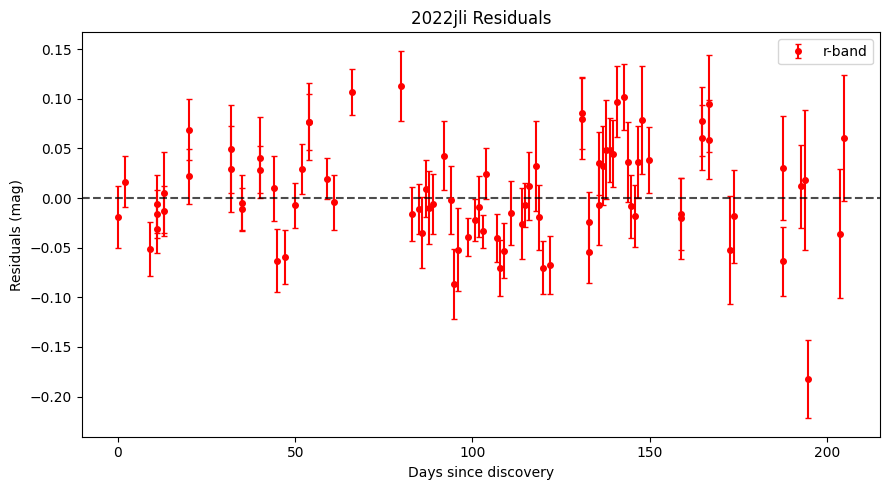

In [58]:
''' plot 2022jli resids'''
import numpy as np
import matplotlib.pyplot as plt

sn_name = "2022jli"
trial_period = 12.4

plt.figure(figsize=(9, 5))

all_residuals = []
all_times = []

for data in grouped_results["poly3"][sn_name][1:]:
    fid = data['fid']
    cand = next(e for e in candidate_library if e["name"] == sn_name and e["fid"] == fid)

    t = np.array(cand["days"])
    mag = np.array(cand['mags'])
    mag_err = np.array(cand['errs'])
    model = data['poly_model']

    residuals = mag - model(t)

    all_residuals.extend(residuals)
    all_times.extend(t)

    plt.errorbar(
        t,
        residuals,
        yerr=mag_err,
        fmt='o',
        color='green' if fid == 1 else 'red',
        markersize=4,
        capsize=2,
        label=f"{'g-band' if fid == 1 else 'r-band'}"
    )

all_residuals = np.array(all_residuals)
all_times = np.array(all_times)

sigma_res = np.std(all_residuals, ddof=1)
N = len(all_residuals)
mda = sigma_res / np.sqrt(N)

# Smooth sinusoid with amplitude = MDA
tt = np.linspace(all_times.min(), all_times.max(), 1000)
demo_signal = mda * np.sin(2 * np.pi * tt / trial_period)

# plt.plot(tt, demo_signal, linewidth=2,
#          label=f"Sinusoid with A = MDA = {mda:.4f} mag")

plt.axhline(0, linestyle='--', color='black', alpha=0.7)

plt.xlabel("Days since discovery")
plt.ylabel("Residuals (mag)")
plt.title("2022jli Residuals")
plt.legend()
plt.tight_layout()
plt.show()


### Plot chi2 vs freq


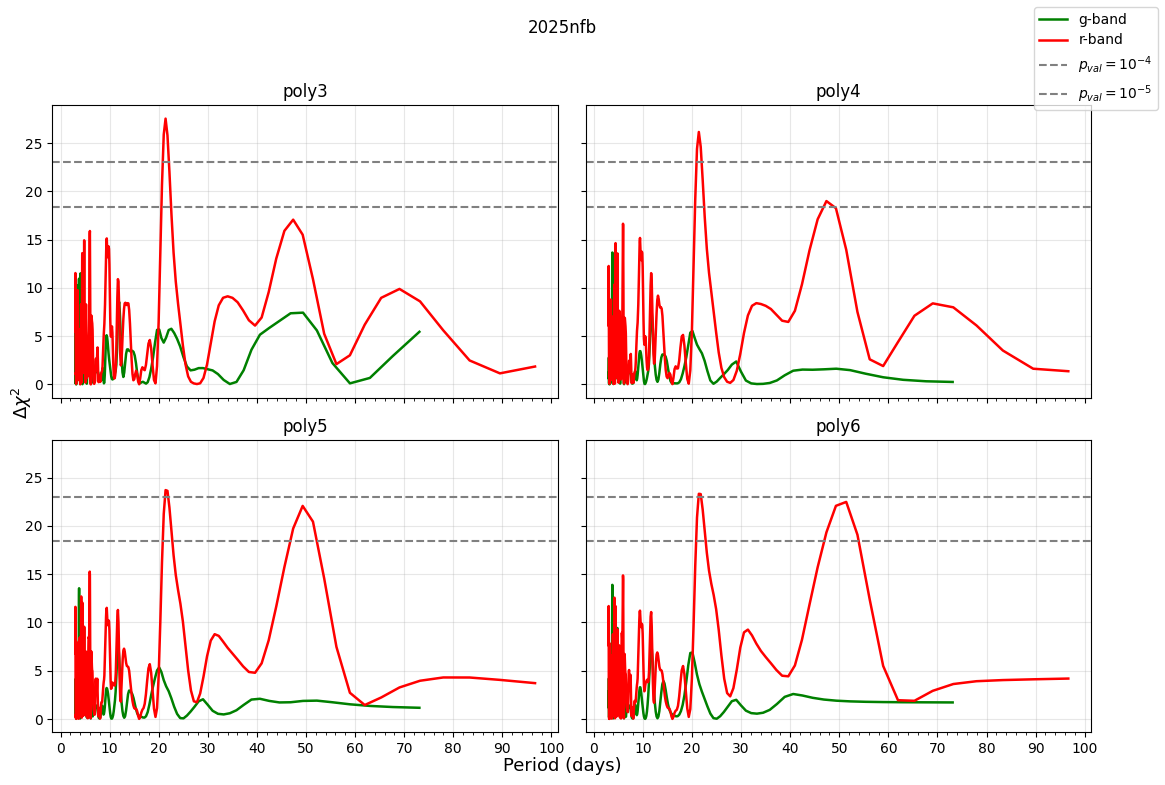

In [20]:
''' plot 4 subplots for all poly methods'''
import matplotlib.pyplot as plt

methods = ["poly3", "poly4", "poly5", "poly6"]
poly_degs = [3, 4, 5, 6]

sn_name = "2025nfb"

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, method, deg in zip(axes, methods, poly_degs):

    # Select both bands from candidate_library
    entries = [
        e for e in candidate_library
        if e["name"] == sn_name
    ]

    for entry in entries:

        fid = entry["fid"]
        days = entry["days"]
        mags = entry["mags"]
        errs = entry["errs"]

        freq, dchi2 = compute_delta_chi2_curve(
            days,
            mags,
            errs,
            poly_deg=deg
        )
        period = 1 / freq        
        color = "green" if fid == 1 else "red"
        label = "g-band" if fid == 1 else "r-band"
        ax.plot(period, dchi2, color=color, lw=1.8,
                label=label)       
    ax.axhline(chi2.ppf(1 - 1e-4, df=2), color='grey', ls='--', lw=1.5, label=r'$p_{val}=10^{-4}$')
    ax.axhline(chi2.ppf(1 - 1e-5, df=2), color='grey', ls='--', lw=1.5, label=r'$p_{val}=10^{-5}$')
    ax.set_title(method)
    ax.grid(alpha=0.3)

    # Dense ticks
    from matplotlib.ticker import MultipleLocator, AutoMinorLocator
    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))


# Axis labels
# fig.text(0.5, 0.04, "Frequency (1/days)", ha='center', fontsize=13)
fig.text(0.5, 0.04, "Period (days)", ha='center', fontsize=13)
fig.text(0.04, 0.5, r"$\Delta \chi^2$", va='center',
         rotation='vertical', fontsize=13)

# Single legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels)
fig.suptitle(sn_name)
plt.tight_layout(rect=[0.04, 0.04, 0.96, 0.96])
# plt.savefig('Figures/2019tsf_periodogram.pdf', dpi=300, bbox_inches='tight')
plt.show()


g-band: f = 0.034951 [0.034164, 0.036505] 1/day, P = 28.611 [27.394, 29.270] days
r-band: f = 0.014306 [nan, 0.016594] 1/day, P = 69.903 [60.261, nan] days


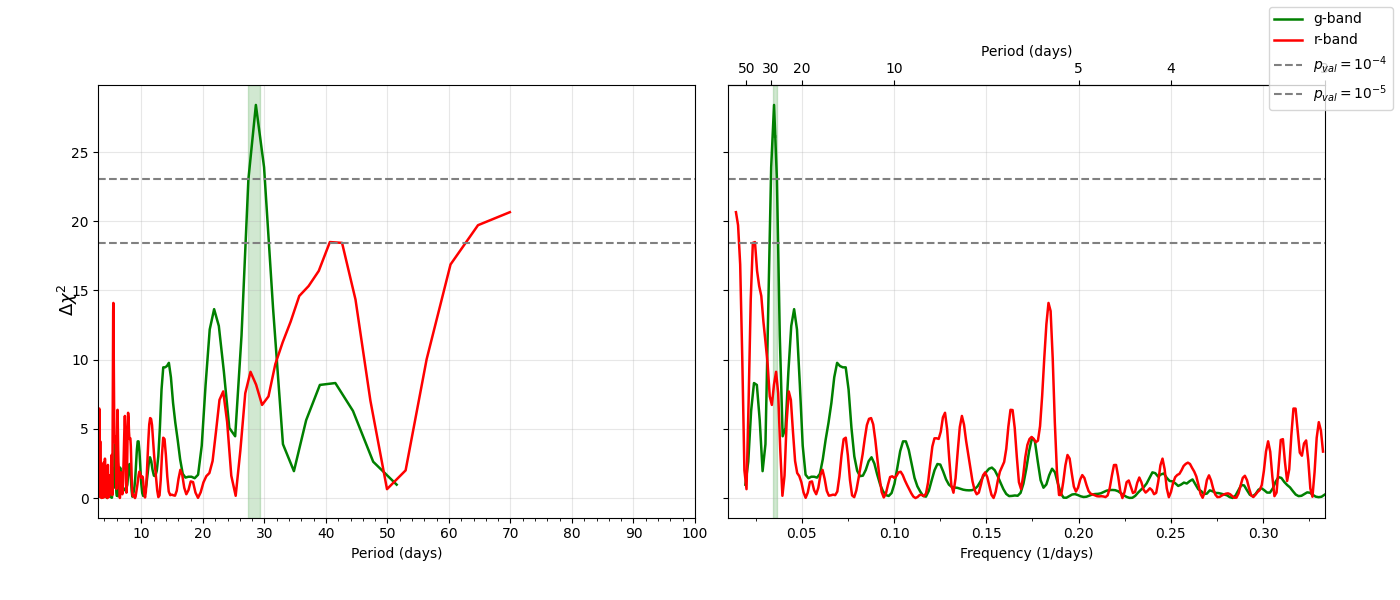

In [87]:
''' plot freq, period with confidence intervals '''
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

from periodicity_tools import find_peak_ci_from_dchi2

sn_name = "2020sgf"

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

ax_period = axes[0]
ax_freq = axes[1]

entries = [
    e for e in candidate_library
    if e["name"] == sn_name
]

for entry in entries:

    fid = entry["fid"]
    days = entry["days"]
    mags = entry["mags"]
    errs = entry["errs"]

    freq, dchi2 = compute_delta_chi2_curve(
        days,
        mags,
        errs,
        poly_deg=3
    )

    period = 1 / freq

    color = "green" if fid == 1 else "red"
    label = "g-band" if fid == 1 else "r-band"

    ax_period.plot(period, dchi2, color=color, lw=1.8, label=label)
    ax_freq.plot(freq, dchi2, color=color, lw=1.8, label=label)

    # confidence interval in frequency space
    f_peak, f_lo, f_hi, ci_level = find_peak_ci_from_dchi2(
        freq,
        dchi2,
        conf=0.68,
        df=2
    )

    # translate CI to period space
    p_peak = 1 / f_peak
    p_lo = 1 / f_hi if np.isfinite(f_hi) else np.nan
    p_hi = 1 / f_lo if np.isfinite(f_lo) else np.nan

    print(
        f"{label}: "
        f"f = {f_peak:.6f} [{f_lo:.6f}, {f_hi:.6f}] 1/day, "
        f"P = {p_peak:.3f} [{p_lo:.3f}, {p_hi:.3f}] days"
    )

    if np.isfinite(f_lo) and np.isfinite(f_hi):

        # horizontal confidence line on frequency plot
        ax_freq.hlines(
            ci_level,
            f_lo,
            f_hi,
            color=color,
            ls=":",
            lw=2
        )

        # shade frequency confidence interval
        ax_freq.axvspan(
            f_lo,
            f_hi,
            color=color,
            alpha=0.18
        )

        # shade corresponding period confidence interval
        ax_period.axvspan(
            p_lo,
            p_hi,
            color=color,
            alpha=0.18
        )

for ax in axes:
    ax.axhline(
        chi2.ppf(1 - 1e-4, df=2),
        color='grey',
        ls='--',
        lw=1.5,
        label=r'$p_{val}=10^{-4}$'
    )

    ax.axhline(
        chi2.ppf(1 - 1e-5, df=2),
        color='grey',
        ls='--',
        lw=1.5,
        label=r'$p_{val}=10^{-5}$'
    )

    ax.grid(alpha=0.3)

ax_period.set_xlabel("Period (days)")
ax_period.set_xlim(3, 100)
ax_period.xaxis.set_major_locator(MultipleLocator(10))
ax_period.xaxis.set_minor_locator(AutoMinorLocator(5))

ax_freq.set_xlabel("Frequency (1/days)")
ax_freq.set_xlim(1/100, 1/3)
ax_freq.xaxis.set_major_locator(MultipleLocator(0.05))
ax_freq.xaxis.set_minor_locator(AutoMinorLocator(2))

def one_over(x):
    x = np.asarray(x)

    return np.divide(
        1.0,
        x,
        out=np.full_like(x, np.nan, dtype=float),
        where=x != 0
    )

secax = ax_freq.secondary_xaxis(
    'top',
    functions=(one_over, one_over)
)

period_ticks = np.array([3, 4, 5, 10, 20, 30, 50])

secax.set_xticks(period_ticks)
secax.set_xticklabels(period_ticks)
secax.set_xlabel("Period (days)")

fig.text(
    0.04,
    0.5,
    r"$\Delta \chi^2$",
    va='center',
    rotation='vertical',
    fontsize=13
)

handles, labels = ax_freq.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

plt.tight_layout(rect=[0.04, 0.04, 0.96, 0.95])
# plt.savefig('Figures/2020sgf_periodogram.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
''' calc period tolerance for 2020sgf'''
P1 = grouped_results["poly3"]["2020sgf"][0]['best_period']
T1 = grouped_results["poly3"]["2020sgf"][0]['time_baseline']
P2 = grouped_results["poly3"]["2020sgf"][1]['best_period']
T2 = grouped_results["poly3"]["2020sgf"][1]['time_baseline']

print("P1^2/T1", P1**2/T1)
print("P2^2/T2", P2**2/T2)
grouped_results["poly3"]["2020sgf"][0]['time_baseline']


P1^2/T1 6.41884263467858
P2^2/T2 7.987175353101369


np.float64(161.74030090030283)

In [12]:
''' find mean MDA'''
mda_values = []

for name, band_results in grouped_results["poly3"].items():
    if name not in dual_band_sne:
        continue
    for res in band_results:
        mda_values.append(res["mda"])
mean_mda = np.mean(mda_values)
percentiles = np.percentile(mda_values, [25, 50, 75])
print(f"Mean MDA across dual-band candidates (poly3): {mean_mda:.3f} mag")
print(f"25th, 50th, 75th percentiles: {percentiles}")


Mean MDA across dual-band candidates (poly3): 0.016 mag
25th, 50th, 75th percentiles: [0.01074637 0.01604926 0.02145646]


### Plot fraction of periodic SNe


In [105]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.stats import binom_conf_interval

TWO_SIGMA = 0.9545

period_thresholds = [10, 20, 30, 40, 50, 60]

double_hits, updated_grouped = find_dual_band_hits(grouped_results, candidate_library)
double_hits = double_hits['poly3']

sn_baselines = {}

for entry in candidate_library:
    name = entry["name"]

    if name not in dual_band_sne:
        continue

    days = np.asarray(entry["days"])
    T = days.max() - days.min()

    # Keep shortest baseline per SN, since that's the limiting factor
    if name not in sn_baselines:
        sn_baselines[name] = T
    else:
        sn_baselines[name] = min(sn_baselines[name], T)

sn_detected_periods = {}

for sn in double_hits:
    band_results = updated_grouped['poly3'][sn]

    best_p1 = band_results[0]['best_period']
    best_p2 = band_results[1]['best_period']

    # Conservative choice: require both bands to be below threshold
    sn_detected_periods[sn] = max(best_p1, best_p2)


fractions = []
lower_bounds = []
upper_bounds = []
valid_counts = []
hit_counts = []

fracs_jli = []
lower_bounds_jli = []
upper_bounds_jli = []

for P in period_thresholds:

    searchable_sne = {
        name for name, T in sn_baselines.items()
        if T > 2.5 * P
    }

    Y = len(searchable_sne)

    detected_sne = {
        sn for sn, Pdet in sn_detected_periods.items()
        if sn in searchable_sne and Pdet < P
    }

    X = len(detected_sne)

    frac = X / Y if Y > 0 else np.nan

    lo, hi = binom_conf_interval(
        X, Y,
        confidence_level=TWO_SIGMA,
        interval='wilson'
    )

    fractions.append(frac)
    lower_bounds.append(lo)
    upper_bounds.append(hi)
    valid_counts.append(Y)
    hit_counts.append(X)

    # 2022jli comparison curve
    X_jli = int(P > 12.4)
    frac_jli = X_jli / Y if Y > 0 else np.nan

    lo_jli, hi_jli = binom_conf_interval(
        X_jli, Y,
        confidence_level=TWO_SIGMA,
        interval='wilson'
    )

    fracs_jli.append(frac_jli)
    lower_bounds_jli.append(lo_jli)
    upper_bounds_jli.append(hi_jli)

    print(
        f"P < {P:>2} days "
        f"(T > {2.5 * P:.1f}): "
        f"X = {X}, Y = {Y}, Fraction = {frac:.3f}"
    )


plt.figure(figsize=(7, 5))

plt.step(
    period_thresholds,
    fractions,
    where='pre',
    color='black',
    linewidth=3,
    label='Cumulative periodic fraction'
)

plt.scatter(
    period_thresholds,
    fractions,
    color='black',
    zorder=3
)

plt.fill_between(
    period_thresholds,
    lower_bounds,
    upper_bounds,
    step='pre',
    color='blue',
    alpha=0.2,
    label=r'2$\sigma$ binomial confidence'
)

plt.step(
    period_thresholds,
    fracs_jli,
    where='pre',
    color='red',
    linewidth=2,
    label='Only SN 2022jli'
)

plt.scatter(
    period_thresholds,
    fracs_jli,
    color='red',
    zorder=3
)

plt.step(
    period_thresholds,
    upper_bounds_jli,
    where='pre',
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=r'2$\sigma$ confidence: only SN 2022jli'
)

plt.step(
    period_thresholds,
    lower_bounds_jli,
    where='pre',
    color='red',
    linestyle='--',
    linewidth=1.5
)

plt.xlabel("Maximum Period $P$ (days)")
plt.ylabel("Fraction of Periodic SNe with Period $<P$")
plt.ylim(0, 0.7)
plt.yticks(np.arange(0, 0.71, 0.05))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

# plt.savefig('Figures/frac_limit.pdf', dpi=300, bbox_inches='tight')
plt.show()


NameError: name 'dual_band_sne' is not defined

Pdet >  5 days (T > 12.5): X = 3, Y = 34, Fraction = 0.088
Pdet > 10 days (T > 25.0): X = 3, Y = 33, Fraction = 0.091
Pdet > 15 days (T > 37.5): X = 2, Y = 32, Fraction = 0.062
Pdet > 20 days (T > 50.0): X = 2, Y = 30, Fraction = 0.067
Pdet > 25 days (T > 62.5): X = 2, Y = 27, Fraction = 0.074
Pdet > 30 days (T > 75.0): X = 2, Y = 26, Fraction = 0.077
Pdet > 35 days (T > 87.5): X = 0, Y = 23, Fraction = 0.000
Pdet > 40 days (T > 100.0): X = 0, Y = 19, Fraction = 0.000


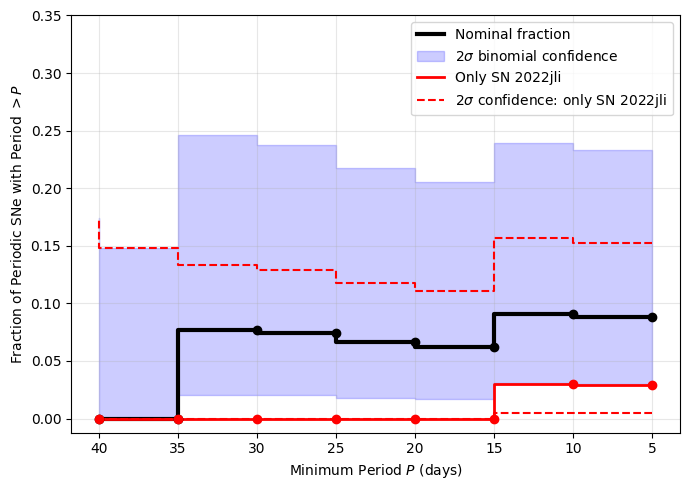

In [60]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.stats import binom_conf_interval

TWO_SIGMA = 0.9545

period_thresholds = np.array([5, 10, 15, 20, 25, 30, 35, 40])

double_hits, updated_grouped = find_dual_band_hits(grouped_results, candidate_library)
double_hits = double_hits['poly3']

sn_baselines = {}

bands_per_sn = defaultdict(set)
for entry in candidate_library:
    bands_per_sn[entry["name"]].add(entry["fid"])
dual_band_sne = {
    name for name, bands in bands_per_sn.items()
    if {1, 2}.issubset(bands)
}


for entry in candidate_library:
    name = entry["name"]

    if name not in dual_band_sne:
        continue

    days = np.asarray(entry["days"])
    T = days.max() - days.min()

    # Keep shortest baseline per SN, since that is the limiting factor
    if name not in sn_baselines:
        sn_baselines[name] = T
    else:
        sn_baselines[name] = min(sn_baselines[name], T)

sn_detected_periods = {}

for sn in double_hits:
    band_results = grouped_results['poly3'][sn]

    best_p1 = band_results[0]['best_period']
    best_p2 = band_results[1]['best_period']

    # Conservative choice: both bands must exceed threshold
    sn_detected_periods[sn] = min(best_p1, best_p2)

fractions = []
lower_bounds = []
upper_bounds = []
valid_counts = []
hit_counts = []

fracs_jli = []
lower_bounds_jli = []
upper_bounds_jli = []

for P in period_thresholds:

    # Denominator:
    # SNe with enough baseline to detect period P.
    # As P decreases, this denominator grows.
    valid_sne = {
        name for name, T in sn_baselines.items()
        if T > 2.5 * P
    }

    Y = len(valid_sne)

    # Numerator:
    # unique detected SNe with detected period larger than P,
    # restricted to the same baseline-complete sample.
    detected_sne = {
        sn for sn, Pdet in sn_detected_periods.items()
        if sn in valid_sne and Pdet > P
    }

    X = len(detected_sne)

    frac = X / Y if Y > 0 else np.nan

    lo, hi = binom_conf_interval(
        X, Y,
        confidence_level=TWO_SIGMA,
        interval='wilson'
    )

    fractions.append(frac)
    lower_bounds.append(lo)
    upper_bounds.append(hi)
    valid_counts.append(Y)
    hit_counts.append(X)

    # SN 2022jli comparison:
    # It contributes when its period is greater than the threshold P.
    X_jli = int(12.4 > P)
    frac_jli = X_jli / Y if Y > 0 else np.nan

    lo_jli, hi_jli = binom_conf_interval(
        X_jli, Y,
        confidence_level=TWO_SIGMA,
        interval='wilson'
    )

    fracs_jli.append(frac_jli)
    lower_bounds_jli.append(lo_jli)
    upper_bounds_jli.append(hi_jli)

    print(
        f"Pdet > {P:>2} days "
        f"(T > {2.5 * P:.1f}): "
        f"X = {X}, Y = {Y}, Fraction = {frac:.3f}"
    )

plt.figure(figsize=(7, 5))

plt.step(
    period_thresholds,
    fractions,
    where='post',
    color='black',
    linewidth=3,
    label='Nominal fraction'
)

plt.scatter(
    period_thresholds,
    fractions,
    color='black',
    zorder=3
)

plt.fill_between(
    period_thresholds,
    lower_bounds,
    upper_bounds,
    step='post',
    color='blue',
    alpha=0.2,
    label=r'2$\sigma$ binomial confidence'
)

plt.step(
    period_thresholds,
    fracs_jli,
    where='post',
    color='red',
    linewidth=2,
    label='Only SN 2022jli'
)

plt.scatter(
    period_thresholds,
    fracs_jli,
    color='red',
    zorder=3
)

plt.step(
    period_thresholds,
    upper_bounds_jli,
    where='post',
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=r'2$\sigma$ confidence: only SN 2022jli'
)

plt.step(
    period_thresholds,
    lower_bounds_jli,
    where='post',
    color='red',
    linestyle='--',
    linewidth=1.5
)

plt.xlabel("Minimum Period $P$ (days)")
plt.ylabel("Fraction of Periodic SNe with Period $>P$")

plt.gca().invert_xaxis()

# plt.ylim(0, 0.4)
plt.yticks(np.arange(0, 0.36, 0.05))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

# plt.savefig('Figures/frac_limit_Pmin.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [121]:
upper_bounds


[np.float64(0.2332997472727948),
 np.float64(0.2394929115503895),
 np.float64(0.2053103738194699),
 np.float64(0.21724279524986057),
 np.float64(0.237983661390943),
 np.float64(0.24580392085606864),
 np.float64(0.14814845656902542)]

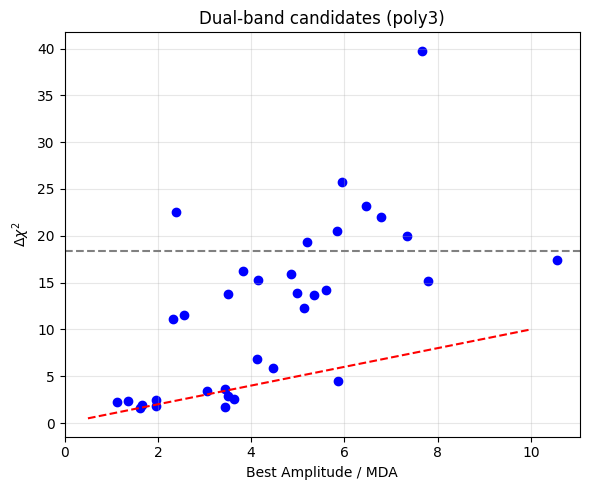

In [61]:
from scipy.stats import chi2

ratios = []
for name in dual_band_sne:
    sgf = grouped_results['poly3'][name]
    mda = max(sgf[1]['mda'], 0.015)
    ratios.append((sgf[1]['best_amplitude']/ mda, sgf[1]['delta_chi2']))

ratios = np.array(ratios)
plt.figure(figsize=(6, 5))
plt.scatter(ratios[:, 0], ratios[:, 1], color='blue')
plt.xlabel("Best Amplitude / MDA")
# plt.axhline(np.sqrt(chi2.ppf(1 - 1e-4, df=2)), color='grey', ls='--', lw=1.5, label=r'$\sqrt{\Delta \chi^2}$ threshold for $p_{val}=10^{-4}$')
plt.axhline(chi2.ppf(1 - 1e-4, df=2), color='grey', ls='--', lw=1.5, label=r'$\sqrt{\Delta \chi^2}$ threshold for $p_{val}=10^{-4}$')
plt.ylabel(r"$ \Delta \chi^2$")
plt.title("Dual-band candidates (poly3)")
plt.grid(alpha=0.3)
xs = np.linspace(0.5, 10, 100)
plt.plot(xs, xs, color='red', ls='--', label="Amplitude = MDA")    
plt.tight_layout()
# plt.savefig('Figures/dual_band_ratios.pdf', dpi=300, bbox_inches='tight')
plt.show()


### Pij grid
instead of fig 5, show a table of P, A, detections, sensitivity (how many could have been detected with injections)


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.stats import chi2
from tqdm.auto import tqdm

from periodicity_tools import analyze_candidate, compute_delta_chi2_curve

N_INJECTIONS = 1000
RNG_SEED = 12345
SHOW_INNER_TQDM = False
SINGLE_FREQ_P = 1e-4
SIG_THRESHOLD = chi2.ppf(1 - SINGLE_FREQ_P, df=2)

period_bins = [(5, 15), (15, 25), (25, 35), (35, 45), (45, 55), (55, 65)]
amplitude_edges = np.round(np.arange(0.00, 0.20 + 0.02, 0.02), 2)


Dual-band sample: 34 candidates


Pij cells:   0%|          | 0/60 [00:00<?, ?it/s]

candidates:   0%|          | 0/32 [00:00<?, ?it/s]

candidates:   0%|          | 0/32 [00:00<?, ?it/s]

candidates:   0%|          | 0/32 [00:00<?, ?it/s]

...

candidates:   0%|          | 0/8 [00:00<?, ?it/s]

candidates:   0%|          | 0/8 [00:00<?, ?it/s]

candidates:   0%|          | 0/8 [00:00<?, ?it/s]

candidates:   0%|          | 0/8 [00:00<?, ?it/s]

candidates:   0%|          | 0/8 [00:00<?, ?it/s]

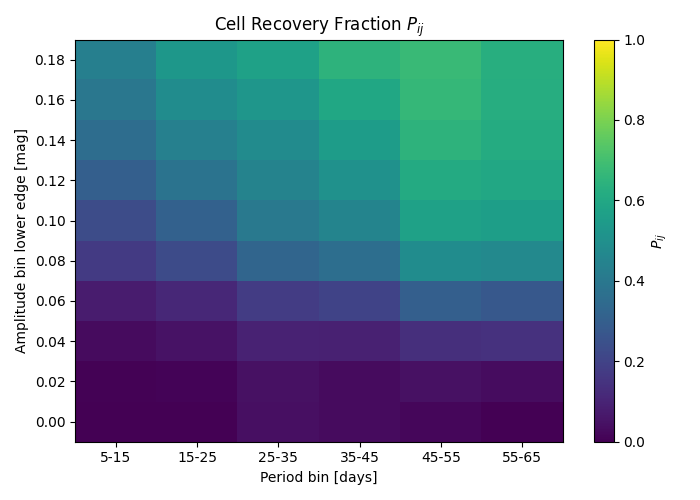

,P_lo,P_hi,A_lo,A_hi,Candidates,RecoveredTrials,InjectionTrials,Pij
0,5,15,0.00,0.02,32,122,32000,0.003812
1,5,15,0.02,0.04,32,193,32000,0.006031
2,5,15,0.04,0.06,32,957,32000,0.029906
3,5,15,0.06,0.08,32,2492,32000,0.077875
4,5,15,0.08,0.10,32,5428,32000,0.169625
5,5,15,0.10,0.12,32,7468,32000,0.233375
6,5,15,0.12,0.14,32,9729,32000,0.304031
7,5,15,0.14,0.16,32,11474,32000,0.358563
8,5,15,0.16,0.18,32,12699,32000,0.396844
9,5,15,0.18,0.20,32,13825,32000,0.432031


In [134]:
''' Create Pij grid'''
rng = np.random.default_rng(RNG_SEED)

entries_by_name = defaultdict(dict)
for entry in candidate_library:
    if entry["fid"] in (1, 2):
        entries_by_name[entry["name"]][entry["fid"]] = entry

poly3_by_name_fid = defaultdict(dict)
for name, band_results in grouped_results["poly3"].items():
    for res in band_results:
        poly3_by_name_fid[name][res["fid"]] = res

dual_band_names = sorted(
    name for name, bands in entries_by_name.items()
    if 1 in bands and 2 in bands and name in grouped_results["poly3"]
)

print(f"Dual-band sample: {len(dual_band_names)} candidates")


def has_peak_near_period(entry, target_period, period_tol):
    freq, dchi2 = compute_delta_chi2_curve(
        entry["days"],
        entry["mags"],
        entry["errs"],
        poly_deg=3,
    )
    periods = 1.0 / freq
    mask = np.abs(periods - target_period) < period_tol

    if not np.any(mask):
        return False

    local_dchi2 = dchi2[mask]

    if len(local_dchi2) < 3:
        return np.nanmax(local_dchi2) > SIG_THRESHOLD

    local_max = (
        (local_dchi2[1:-1] > local_dchi2[:-2]) &
        (local_dchi2[1:-1] > local_dchi2[2:])
    )

    if not np.any(local_max):
        return np.nanmax(local_dchi2) > SIG_THRESHOLD

    return np.any(local_dchi2[1:-1][local_max] > SIG_THRESHOLD)


def recovered_in_both_bands(sim_entries, injected_period):
    results = []

    for entry in sim_entries:
        res = analyze_candidate(
            entry["name"],
            entry["days"],
            entry["mags"],
            entry["errs"],
            poly_deg=3,
        )
        res["fid"] = entry["fid"]
        results.append(res)

    r1, r2 = results

    if not (
        r1["p_value_single_freq"] < SINGLE_FREQ_P and
        r2["p_value_single_freq"] < SINGLE_FREQ_P and
        r1["best_amplitude"] >= r1["mda"] and
        r2["best_amplitude"] >= r2["mda"]
    ):
        return False

    period_tol = max(
        r1["best_period"] ** 2 / r1["time_baseline"],
        r2["best_period"] ** 2 / r2["time_baseline"],
    )
    period_tol = min(0.1 * injected_period, period_tol)

    if not (
        abs(r1["best_period"] - injected_period) < period_tol or
        abs(r2["best_period"] - injected_period) < period_tol
    ):
        return False

    return all(has_peak_near_period(entry, injected_period, period_tol) for entry in sim_entries)


def make_injected_light_curve(entry, period, amplitude, rng):
    days = np.asarray(entry["days"])
    mags = np.asarray(entry["mags"])

    phase = rng.uniform(0.0, 2.0 * np.pi)
    signal = amplitude * np.sin(2.0 * np.pi * days / period + phase)

    sim_entry = entry.copy()
    sim_entry["mags"] = mags + signal
    return sim_entry


rows = []
cell_grid = [
    (p_lo, p_hi, a_lo, a_hi)
    for p_lo, p_hi in period_bins
    for a_lo, a_hi in zip(amplitude_edges[:-1], amplitude_edges[1:])
]

for cell_i, (p_lo, p_hi, a_lo, a_hi) in enumerate(
    tqdm(cell_grid, desc="Pij cells", dynamic_ncols=True),
    start=1,
):
    eligible_names = []

    for name in dual_band_names:
        p_max = min(
            poly3_by_name_fid[name][1]["time_baseline"],
            poly3_by_name_fid[name][2]["time_baseline"],
        ) / 2.5

        # Candidate must be able to cover the whole period bin.
        if p_max >= p_hi:
            eligible_names.append(name)

    # tqdm.write(
    #     f"[{cell_i}/{len(cell_grid)}] "
    #     f"P=[{p_lo}, {p_hi}), A=[{a_lo:.2f}, {a_hi:.2f}): "
    #     f"{len(eligible_names)} eligible candidates"
    # )

    recovery_rates = []
    recovered_total = 0
    trials_total = 0

    for name in tqdm(eligible_names, desc="candidates", leave=False, position=1, dynamic_ncols=True):
        recovered = 0

        injection_iter = tqdm(
            range(N_INJECTIONS),
            desc=name,
            leave=False,
            position=2,
            dynamic_ncols=True,
            disable=not SHOW_INNER_TQDM,
        )

        for _ in injection_iter:
            injected_period = rng.uniform(p_lo, p_hi)
            injected_amplitude = rng.uniform(a_lo, a_hi)

            sim_entries = [
                make_injected_light_curve(entries_by_name[name][fid], injected_period, injected_amplitude, rng)
                for fid in (1, 2)
            ]

            recovered += int(recovered_in_both_bands(sim_entries, injected_period))

        recovery_rates.append(recovered / N_INJECTIONS)
        recovered_total += recovered
        trials_total += N_INJECTIONS

    Pij = float(np.mean(recovery_rates)) if recovery_rates else np.nan

    rows.append({
        "P_lo": p_lo,
        "P_hi": p_hi,
        "A_lo": a_lo,
        "A_hi": a_hi,
        "Candidates": len(eligible_names),
        "RecoveredTrials": recovered_total,
        "InjectionTrials": trials_total,
        "Pij": Pij,
    })

Pij_table = pd.DataFrame(rows)
Pij_table.to_csv("Pij_recovery_table.csv", index=False)

Pij_map = (
    Pij_table
    .pivot(index="A_lo", columns="P_lo", values="Pij")
    .sort_index()
)

fig, ax = plt.subplots(figsize=(7, 5))

im = ax.imshow(
    Pij_map.values,
    origin="lower",
    aspect="auto",
    cmap="viridis",
    vmin=0,
    vmax=1,
)

ax.set_xticks(np.arange(len(Pij_map.columns)))
ax.set_xticklabels([f"{int(p)}-{int(dict(period_bins)[p])}" for p in Pij_map.columns])

ax.set_yticks(np.arange(len(Pij_map.index)))
ax.set_yticklabels([f"{a:.2f}" for a in Pij_map.index])

ax.set_xlabel("Period bin [days]")
ax.set_ylabel("Amplitude bin lower edge [mag]")
ax.set_title("Cell Recovery Fraction $P_{ij}$")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("$P_{ij}$")

plt.tight_layout()
plt.show()

Pij_table


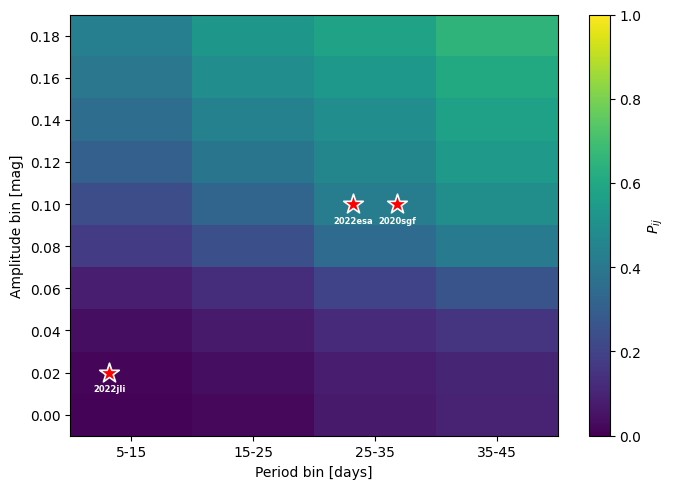

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

Pij_table = pd.read_csv("Pij_recovery_table_prev.csv")
Pij_map = (
    Pij_table
    .pivot(index="A_lo", columns="P_lo", values="Pij")
    .sort_index()
)


fig, ax = plt.subplots(figsize=(7, 5))

im = ax.imshow(
    Pij_map.values,
    origin="lower",
    aspect="auto",
    cmap="viridis",
    vmin=0,
    vmax=1,
)

# for name, br in updated_grouped["poly3"].items():
#     P = min(r["best_period"] for r in br)
#     A = min(r["best_amplitude"] for r in br)

#     hit = Pij_table[
#         (Pij_table["P_lo"] <= P) & (P < Pij_table["P_hi"]) &
#         (Pij_table["A_lo"] <= A) & (A < Pij_table["A_hi"])
#     ]

#     if hit.empty:
#         print(f"{name} outside grid: P={P:.1f}, A={A:.2f}")
#         continue

#     x = np.where(Pij_map.columns.to_numpy(float) == hit.iloc[0]["P_lo"])[0][0]
#     y = np.where(Pij_map.index.to_numpy(float) == hit.iloc[0]["A_lo"])[0][0]

#     ax.scatter(x, y, marker="*", s=220, c="red", edgecolor="white", linewidth=1.2, zorder=5)
#     ax.text(x + 0.08, y + 0.08, name, color="white", fontsize=9, weight="bold", zorder=6)
from collections import defaultdict
bin_counts = defaultdict(int)
for name, br in updated_grouped["poly3"].items():
    P = min(r["best_period"] for r in br)
    A = min(r["best_amplitude"] for r in br)

    hit = Pij_table[
        (Pij_table["P_lo"] <= P) & (P < Pij_table["P_hi"]) &
        (Pij_table["A_lo"] <= A) & (A < Pij_table["A_hi"])
    ]

    if hit.empty:
        print(f"{name} outside grid: P={P:.1f}, A={A:.2f}")
        continue

    x = np.where(Pij_map.columns.to_numpy(float) == hit.iloc[0]["P_lo"])[0][0]
    y = np.where(Pij_map.index.to_numpy(float) == hit.iloc[0]["A_lo"])[0][0]

    key = (x, y)
    k = bin_counts[key]
    bin_counts[key] += 1

    offsets = [(-0.18, 0.00), (0.18, 0.00), (0.00, 0.18), (0.00, -0.18)]
    dx, dy = offsets[k % len(offsets)]

    ax.scatter(
        x + dx,
        y + dy,
        marker="*",
        s=220,
        c="red",
        edgecolor="white",
        linewidth=1.2,
        zorder=5,
    )

    ax.text(
        x + dx,
        y + dy - 0.28,
        name,
        color="white",
        fontsize=6,
        weight="bold",
        ha="center",
        va="top",
        zorder=6,
    )


ax.set_xticks(np.arange(len(Pij_map.columns)))
ax.set_xticklabels([f"{int(p)}-{int(dict(period_bins)[p])}" for p in Pij_map.columns])

ax.set_yticks(np.arange(len(Pij_map.index)))
ax.set_yticklabels([f"{a:.2f}" for a in Pij_map.index])

ax.set_xlabel("Period bin [days]")
ax.set_ylabel("Amplitude bin [mag]")


cbar = fig.colorbar(im, ax=ax)
cbar.set_label("$P_{ij}$")

plt.tight_layout()
# plt.savefig('Figures/Pij_recovery_map.pdf', dpi=300, bbox_inches='tight')
plt.show()


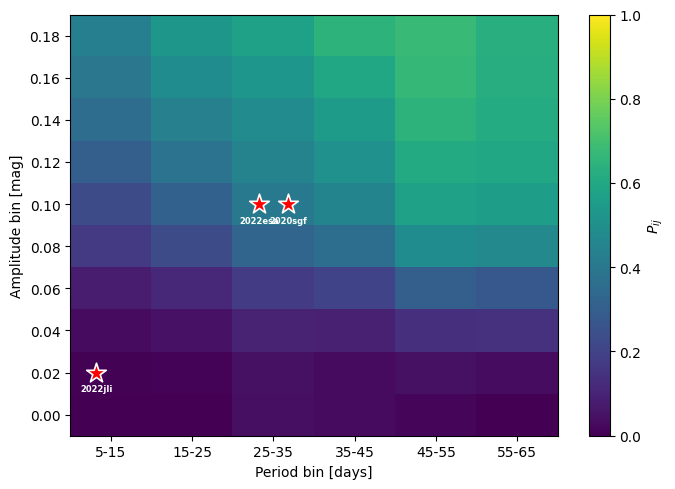

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

Pij_table = pd.read_csv("Pij_recovery_table.csv")
Pij_map = (
    Pij_table
    .pivot(index="A_lo", columns="P_lo", values="Pij")
    .sort_index()
)


fig, ax = plt.subplots(figsize=(7, 5))

im = ax.imshow(
    Pij_map.values,
    origin="lower",
    aspect="auto",
    cmap="viridis",
    vmin=0,
    vmax=1,
)

# for name, br in updated_grouped["poly3"].items():
#     P = min(r["best_period"] for r in br)
#     A = min(r["best_amplitude"] for r in br)

#     hit = Pij_table[
#         (Pij_table["P_lo"] <= P) & (P < Pij_table["P_hi"]) &
#         (Pij_table["A_lo"] <= A) & (A < Pij_table["A_hi"])
#     ]

#     if hit.empty:
#         print(f"{name} outside grid: P={P:.1f}, A={A:.2f}")
#         continue

#     x = np.where(Pij_map.columns.to_numpy(float) == hit.iloc[0]["P_lo"])[0][0]
#     y = np.where(Pij_map.index.to_numpy(float) == hit.iloc[0]["A_lo"])[0][0]

#     ax.scatter(x, y, marker="*", s=220, c="red", edgecolor="white", linewidth=1.2, zorder=5)
#     ax.text(x + 0.08, y + 0.08, name, color="white", fontsize=9, weight="bold", zorder=6)
from collections import defaultdict
bin_counts = defaultdict(int)
for name, br in updated_grouped["poly3"].items():
    P = min(r["best_period"] for r in br)
    A = min(r["best_amplitude"] for r in br)

    hit = Pij_table[
        (Pij_table["P_lo"] <= P) & (P < Pij_table["P_hi"]) &
        (Pij_table["A_lo"] <= A) & (A < Pij_table["A_hi"])
    ]

    if hit.empty:
        print(f"{name} outside grid: P={P:.1f}, A={A:.2f}")
        continue

    x = np.where(Pij_map.columns.to_numpy(float) == hit.iloc[0]["P_lo"])[0][0]
    y = np.where(Pij_map.index.to_numpy(float) == hit.iloc[0]["A_lo"])[0][0]

    key = (x, y)
    k = bin_counts[key]
    bin_counts[key] += 1

    offsets = [(-0.18, 0.00), (0.18, 0.00), (0.00, 0.18), (0.00, -0.18)]
    dx, dy = offsets[k % len(offsets)]

    ax.scatter(
        x + dx,
        y + dy,
        marker="*",
        s=220,
        c="red",
        edgecolor="white",
        linewidth=1.2,
        zorder=5,
    )

    ax.text(
        x + dx,
        y + dy - 0.28,
        name,
        color="white",
        fontsize=6,
        weight="bold",
        ha="center",
        va="top",
        zorder=6,
    )


ax.set_xticks(np.arange(len(Pij_map.columns)))
ax.set_xticklabels([f"{int(p)}-{int(dict(period_bins)[p])}" for p in Pij_map.columns])

ax.set_yticks(np.arange(len(Pij_map.index)))
ax.set_yticklabels([f"{a:.2f}" for a in Pij_map.index])

ax.set_xlabel("Period bin [days]")
ax.set_ylabel("Amplitude bin [mag]")


cbar = fig.colorbar(im, ax=ax)
cbar.set_label("$P_{ij}$")

plt.tight_layout()
plt.savefig('Figures/Pij_recovery_map.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [138]:
# FIGURE OUT WHY SENSITIVTY GROWS WITH LONGER PERIODS?

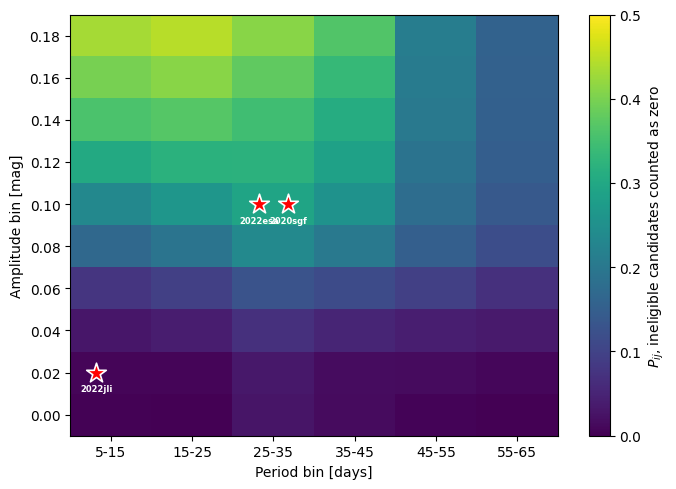

,P_lo,P_hi,A_lo,A_hi,Candidates,Pij,Pij_full_sample
0,5,15,0.00,0.02,32,0.003812,0.003812
1,5,15,0.02,0.04,32,0.006031,0.006031
2,5,15,0.04,0.06,32,0.029906,0.029906
3,5,15,0.06,0.08,32,0.077875,0.077875
4,5,15,0.08,0.10,32,0.169625,0.169625
5,5,15,0.10,0.12,32,0.233375,0.233375
6,5,15,0.12,0.14,32,0.304031,0.304031
7,5,15,0.14,0.16,32,0.358563,0.358563
8,5,15,0.16,0.18,32,0.396844,0.396844
9,5,15,0.18,0.20,32,0.432031,0.432031


In [30]:
Pij_table = pd.read_csv("Pij_recovery_table.csv")

# The original Pij is conditional on having enough baseline for the period bin.
# Here, candidates that are ineligible for a period bin count as zero recovery.
n_full_sample = int(Pij_table["Candidates"].max())
n_injections_per_candidate = int((Pij_table["InjectionTrials"] / Pij_table["Candidates"]).median())

Pij_table = Pij_table.copy()
Pij_table["Pij_full_sample"] = (
    Pij_table["RecoveredTrials"] / (n_full_sample * n_injections_per_candidate)
)

Pij_full_map = (
    Pij_table
    .pivot(index="A_lo", columns="P_lo", values="Pij_full_sample")
    .sort_index()
)

period_labels = (
    Pij_table.drop_duplicates("P_lo")
    .set_index("P_lo")["P_hi"]
    .to_dict()
)

fig, ax = plt.subplots(figsize=(7, 5))

im = ax.imshow(
    Pij_full_map.values,
    origin="lower",
    aspect="auto",
    cmap="viridis",
    vmin=0,
    vmax=0.5,
)
from collections import defaultdict
bin_counts = defaultdict(int)
for name, br in updated_grouped["poly3"].items():
    P = min(r["best_period"] for r in br)
    A = min(r["best_amplitude"] for r in br)

    hit = Pij_table[
        (Pij_table["P_lo"] <= P) & (P < Pij_table["P_hi"]) &
        (Pij_table["A_lo"] <= A) & (A < Pij_table["A_hi"])
    ]

    if hit.empty:
        print(f"{name} outside grid: P={P:.1f}, A={A:.2f}")
        continue

    x = np.where(Pij_map.columns.to_numpy(float) == hit.iloc[0]["P_lo"])[0][0]
    y = np.where(Pij_map.index.to_numpy(float) == hit.iloc[0]["A_lo"])[0][0]

    key = (x, y)
    k = bin_counts[key]
    bin_counts[key] += 1

    offsets = [(-0.18, 0.00), (0.18, 0.00), (0.00, 0.18), (0.00, -0.18)]
    dx, dy = offsets[k % len(offsets)]

    ax.scatter(
        x + dx,
        y + dy,
        marker="*",
        s=220,
        c="red",
        edgecolor="white",
        linewidth=1.2,
        zorder=5,
    )

    ax.text(
        x + dx,
        y + dy - 0.28,
        name,
        color="white",
        fontsize=6,
        weight="bold",
        ha="center",
        va="top",
        zorder=6,
    )
ax.set_xticks(np.arange(len(Pij_full_map.columns)))
ax.set_xticklabels([
    f"{int(p)}-{int(period_labels[p])}"
    for p in Pij_full_map.columns
])

ax.set_yticks(np.arange(len(Pij_full_map.index)))
ax.set_yticklabels([f"{a:.2f}" for a in Pij_full_map.index])

ax.set_xlabel("Period bin [days]")
ax.set_ylabel("Amplitude bin [mag]")
# ax.set_title(f"Full-sample recovery probability, N={n_full_sample}")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("$P_{ij}$, ineligible candidates counted as zero")

plt.tight_layout()
plt.savefig("Figures/Pij_full_sample_recovery_map.pdf", dpi=300, bbox_inches="tight")
plt.show()

Pij_table[[
    "P_lo", "P_hi", "A_lo", "A_hi", "Candidates", "Pij", "Pij_full_sample"
]]


2022esa diagnostic injections:   0%|          | 0/1000 [00:00<?, ?it/s]

2022esa, P=(5, 15), A=(0.14, 0.16): 9/1000 recovered (0.009)
min dual-band baseline=119.7 d, p_max=47.9 d
Example success: injected P=7.76 d, A=0.158 mag, period_tol=0.50 d
fid=1: best P=7.73 d, A=0.206, MDA=0.036, p=8.28e-05, dchi2=18.8
fid=2: best P=7.72 d, A=0.173, MDA=0.025, p=2.71e-05, dchi2=21.0


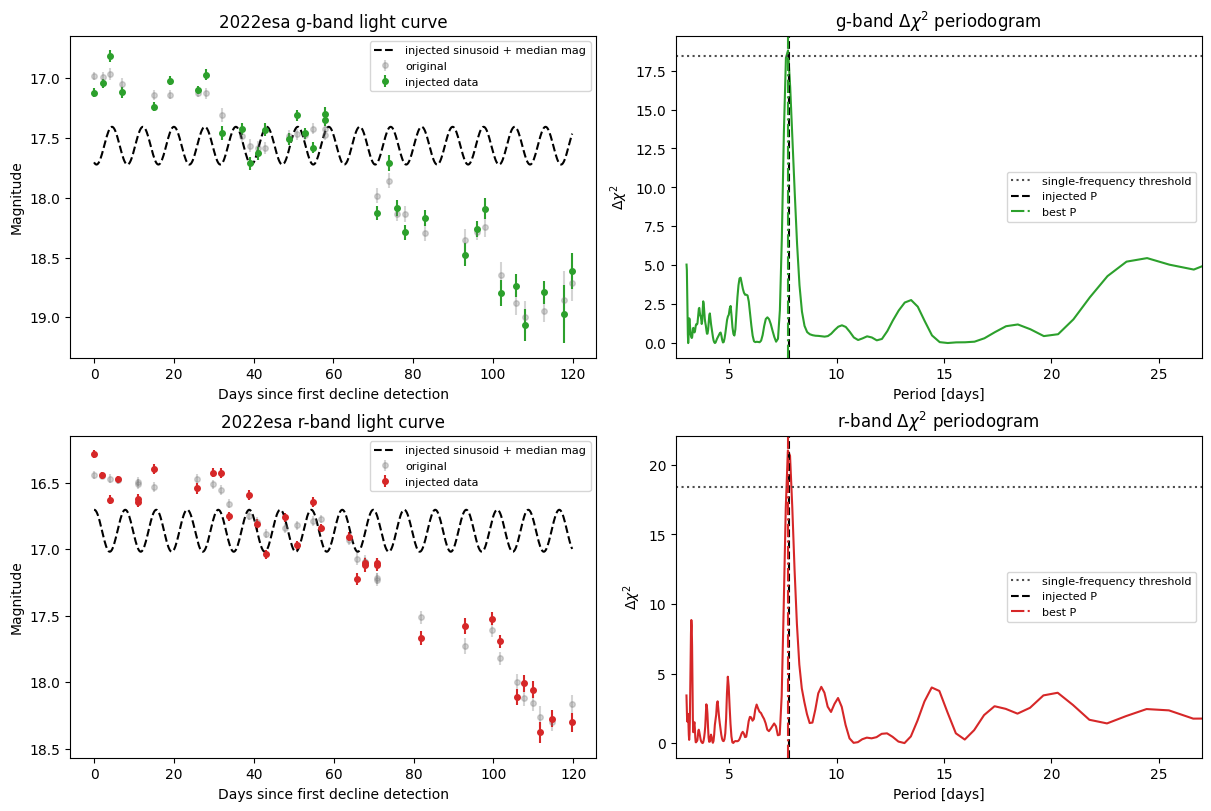

In [18]:
# Diagnostic: single-candidate injection recovery and one successful trial
from collections import defaultdict
from scipy.stats import chi2
from tqdm.auto import tqdm

from periodicity_tools import analyze_candidate, compute_delta_chi2_curve

DIAG_NAME = "2022esa"
DIAG_PERIOD_BIN = (5, 15)
DIAG_AMPLITUDE_BIN = (0.14, 0.16)
DIAG_N_INJECTIONS = 1000
DIAG_RNG_SEED = 20260708
DIAG_POLY_DEG = 3
DIAG_SINGLE_FREQ_P = 1e-4
DIAG_SIG_THRESHOLD = chi2.ppf(1 - DIAG_SINGLE_FREQ_P, df=2)


def diag_build_dual_band_entries(candidate_library):
    entries = defaultdict(dict)
    for entry in candidate_library:
        if entry["fid"] in (1, 2):
            entries[entry["name"]][entry["fid"]] = entry
    return entries


def diag_has_peak_near_period(entry, target_period, period_tol):
    freq, dchi2 = compute_delta_chi2_curve(
        entry["days"],
        entry["mags"],
        entry["errs"],
        poly_deg=DIAG_POLY_DEG,
    )
    periods = 1.0 / freq
    mask = np.abs(periods - target_period) < period_tol

    if not np.any(mask):
        return False

    local_dchi2 = dchi2[mask]

    if len(local_dchi2) < 3:
        return np.nanmax(local_dchi2) > DIAG_SIG_THRESHOLD

    local_max = (
        (local_dchi2[1:-1] > local_dchi2[:-2]) &
        (local_dchi2[1:-1] > local_dchi2[2:])
    )

    if not np.any(local_max):
        return np.nanmax(local_dchi2) > DIAG_SIG_THRESHOLD

    return np.any(local_dchi2[1:-1][local_max] > DIAG_SIG_THRESHOLD)


def diag_make_injected_light_curve(entry, period, amplitude, rng):
    days = np.asarray(entry["days"])
    mags = np.asarray(entry["mags"])

    # This matches the current Pij map code: the phase is drawn per band.
    phase = rng.uniform(0.0, 2.0 * np.pi)
    signal = amplitude * np.sin(2.0 * np.pi * days / period + phase)

    sim_entry = entry.copy()
    sim_entry["mags"] = mags + signal
    sim_entry["injected_signal"] = signal
    sim_entry["injected_phase"] = phase
    sim_entry["injected_period"] = period
    sim_entry["injected_amplitude"] = amplitude
    return sim_entry


def diag_recovered_in_both_bands(sim_entries, injected_period):
    results = []

    for entry in sim_entries:
        res = analyze_candidate(
            entry["name"],
            entry["days"],
            entry["mags"],
            entry["errs"],
            poly_deg=DIAG_POLY_DEG,
        )
        res["fid"] = entry["fid"]
        results.append(res)

    r1, r2 = results

    passed_basic = (
        r1["p_value_single_freq"] < DIAG_SINGLE_FREQ_P and
        r2["p_value_single_freq"] < DIAG_SINGLE_FREQ_P and
        r1["best_amplitude"] >= r1["mda"] and
        r2["best_amplitude"] >= r2["mda"]
    )

    period_tol = max(
        r1["best_period"] ** 2 / r1["time_baseline"],
        r2["best_period"] ** 2 / r2["time_baseline"],
    )
    period_tol = min(0.1 * injected_period, period_tol)

    passed_best_period = (
        abs(r1["best_period"] - injected_period) < period_tol or
        abs(r2["best_period"] - injected_period) < period_tol
    )

    passed_local_peak = all(
        diag_has_peak_near_period(entry, injected_period, period_tol)
        for entry in sim_entries
    )

    recovered = passed_basic and passed_best_period and passed_local_peak

    return recovered, results, period_tol, {
        "passed_basic": passed_basic,
        "passed_best_period": passed_best_period,
        "passed_local_peak": passed_local_peak,
    }


diag_entries_by_name = diag_build_dual_band_entries(candidate_library)
if DIAG_NAME not in diag_entries_by_name or not {1, 2}.issubset(diag_entries_by_name[DIAG_NAME]):
    raise ValueError(f"{DIAG_NAME} is not a dual-band candidate in candidate_library")

diag_entries = [diag_entries_by_name[DIAG_NAME][fid] for fid in (1, 2)]
diag_min_baseline = min(np.ptp(entry["days"]) for entry in diag_entries)
diag_p_max = diag_min_baseline / 2.5
if diag_p_max < DIAG_PERIOD_BIN[1]:
    raise ValueError(
        f"{DIAG_NAME} is not eligible for P={DIAG_PERIOD_BIN}: "
        f"p_max={diag_p_max:.2f} d"
    )

diag_rng = np.random.default_rng(DIAG_RNG_SEED)
diag_recovered = 0
diag_success = None

for _ in tqdm(range(DIAG_N_INJECTIONS), desc=f"{DIAG_NAME} diagnostic injections"):
    injected_period = diag_rng.uniform(*DIAG_PERIOD_BIN)
    injected_amplitude = diag_rng.uniform(*DIAG_AMPLITUDE_BIN)

    sim_entries = [
        diag_make_injected_light_curve(entry, injected_period, injected_amplitude, diag_rng)
        for entry in diag_entries
    ]

    recovered, results, period_tol, checks = diag_recovered_in_both_bands(
        sim_entries,
        injected_period,
    )

    if recovered:
        diag_recovered += 1
        if diag_success is None:
            diag_success = {
                "period": injected_period,
                "amplitude": injected_amplitude,
                "entries": sim_entries,
                "results": results,
                "period_tol": period_tol,
                "checks": checks,
            }

diag_recovery_rate = diag_recovered / DIAG_N_INJECTIONS
print(
    f"{DIAG_NAME}, P={DIAG_PERIOD_BIN}, A={DIAG_AMPLITUDE_BIN}: "
    f"{diag_recovered}/{DIAG_N_INJECTIONS} recovered "
    f"({diag_recovery_rate:.3f})"
)
print(f"min dual-band baseline={diag_min_baseline:.1f} d, p_max={diag_p_max:.1f} d")

if diag_success is None:
    print("No successful trial found. Try a higher amplitude bin or a different candidate.")
else:
    print(
        f"Example success: injected P={diag_success['period']:.2f} d, "
        f"A={diag_success['amplitude']:.3f} mag, "
        f"period_tol={diag_success['period_tol']:.2f} d"
    )
    for res in diag_success["results"]:
        print(
            f"fid={res['fid']}: best P={res['best_period']:.2f} d, "
            f"A={res['best_amplitude']:.3f}, MDA={res['mda']:.3f}, "
            f"p={res['p_value_single_freq']:.2e}, dchi2={res['delta_chi2']:.1f}"
        )

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
    band_styles = {
        1: {"label": "g", "color": "tab:green"},
        2: {"label": "r", "color": "tab:red"},
    }

    for row, (entry, res) in enumerate(zip(diag_success["entries"], diag_success["results"])):
        fid = entry["fid"]
        style = band_styles[fid]
        original = diag_entries_by_name[DIAG_NAME][fid]
        days = np.asarray(entry["days"])
        mags = np.asarray(entry["mags"])
        errs = np.asarray(entry["errs"])
        signal = np.asarray(entry["injected_signal"])

        ax_lc = axes[row, 0]
        ax_lc.errorbar(
            original["days"],
            original["mags"],
            yerr=original["errs"],
            fmt="o",
            ms=4,
            alpha=0.30,
            color="0.45",
            label="original",
        )
        ax_lc.errorbar(
            days,
            mags,
            yerr=errs,
            fmt="o",
            ms=4,
            color=style["color"],
            label="injected data",
        )

        t_grid = np.linspace(days.min(), days.max(), 600)
        signal_grid = diag_success["amplitude"] * np.sin(
            2.0 * np.pi * t_grid / diag_success["period"] + entry["injected_phase"]
        )
        ax_lc.plot(
            t_grid,
            np.nanmedian(original["mags"]) + signal_grid,
            "--",
            color="black",
            lw=1.5,
            label="injected sinusoid + median mag",
        )
        ax_lc.invert_yaxis()
        ax_lc.set_title(f"{DIAG_NAME} {style['label']}-band light curve")
        ax_lc.set_xlabel("Days since first decline detection")
        ax_lc.set_ylabel("Magnitude")
        ax_lc.legend(fontsize=8)

        freq, dchi2 = compute_delta_chi2_curve(days, mags, errs, poly_deg=DIAG_POLY_DEG)
        periods = 1.0 / freq
        ax_pg = axes[row, 1]
        ax_pg.plot(periods, dchi2, color=style["color"], lw=1.5)
        ax_pg.axhline(DIAG_SIG_THRESHOLD, color="0.3", ls=":", label="single-frequency threshold")
        ax_pg.axvline(diag_success["period"], color="black", ls="--", label="injected P")
        ax_pg.axvline(res["best_period"], color=style["color"], ls="-.", label="best P")
        ax_pg.set_xlim(DIAG_PERIOD_BIN[0] * 0.5, DIAG_PERIOD_BIN[1] * 1.8)
        ax_pg.set_title(f"{style['label']}-band $\\Delta\\chi^2$ periodogram")
        ax_pg.set_xlabel("Period [days]")
        ax_pg.set_ylabel("$\\Delta\\chi^2$")
        ax_pg.legend(fontsize=8)

    plt.show()


candidates:   0%|          | 0/34 [00:00<?, ?it/s]

2018cbz:   0%|          | 0/6 [00:00<?, ?it/s]

2018gle:   0%|          | 0/6 [00:00<?, ?it/s]

2019ieh:   0%|          | 0/6 [00:00<?, ?it/s]

2019odp:   0%|          | 0/6 [00:00<?, ?it/s]

...

2024gry:   0%|          | 0/6 [00:00<?, ?it/s]

2024pwk:   0%|          | 0/6 [00:00<?, ?it/s]

2024rbc:   0%|          | 0/6 [00:00<?, ?it/s]

2025pb:   0%|          | 0/6 [00:00<?, ?it/s]

2025shi:   0%|          | 0/6 [00:00<?, ?it/s]

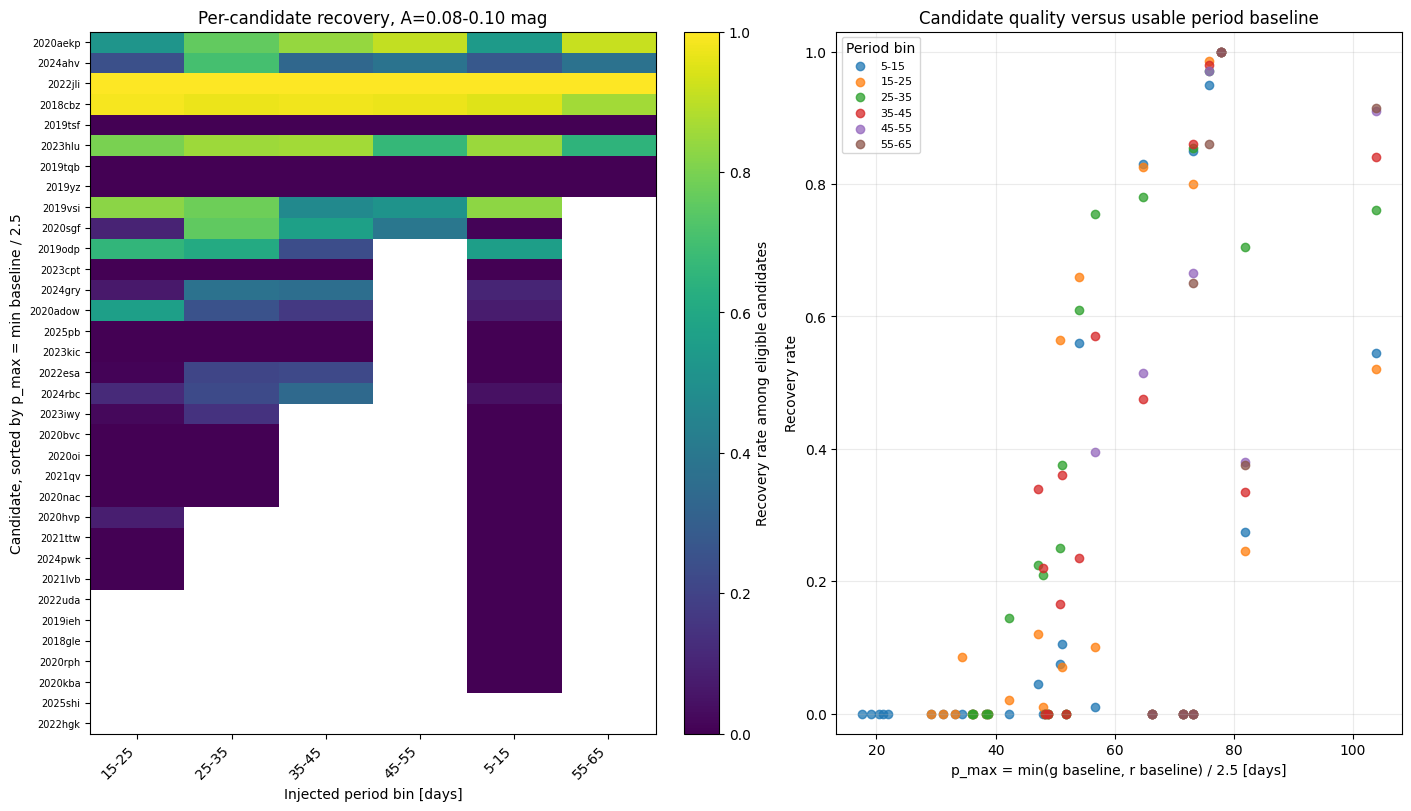

,P_lo,P_hi,period_bin,n_eligible,mean_conditional_recovery,mean_full_sample_recovery,median_p_max_eligible
0,5,15,5-15,32,0.163906,0.154265,48.109046
1,15,25,15-25,27,0.222407,0.176618,50.758407
2,25,35,25-35,23,0.332174,0.224706,51.884181
3,35,45,35-45,18,0.354444,0.187647,60.700074
4,45,55,45-55,10,0.483500,0.142206,73.071757
5,55,65,55-65,8,0.475000,0.111765,74.471259


,name,P_lo,P_hi,period_bin,A_lo,A_hi,min_baseline,p_max,eligible,recovered,trials,recovery_rate,recovery_rate_full_sample
126,2022hgk,5,15,5-15,0.08,0.1,23.923310,9.569324,False,0,0,NaN,0.000
127,2022hgk,15,25,15-25,0.08,0.1,23.923310,9.569324,False,0,0,NaN,0.000
128,2022hgk,25,35,25-35,0.08,0.1,23.923310,9.569324,False,0,0,NaN,0.000
129,2022hgk,35,45,35-45,0.08,0.1,23.923310,9.569324,False,0,0,NaN,0.000
130,2022hgk,45,55,45-55,0.08,0.1,23.923310,9.569324,False,0,0,NaN,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
55,2020aekp,15,25,15-25,0.08,0.1,259.585833,103.834333,True,104,200,0.520,0.520
56,2020aekp,25,35,25-35,0.08,0.1,259.585833,103.834333,True,152,200,0.760,0.760
57,2020aekp,35,45,35-45,0.08,0.1,259.585833,103.834333,True,168,200,0.840,0.840
58,2020aekp,45,55,45-55,0.08,0.1,259.585833,103.834333,True,182,200,0.910,0.910


In [21]:
# Diagnostic: does longer baseline select intrinsically better injection-recovery candidates?
from collections import defaultdict
from scipy.stats import chi2
from tqdm.auto import tqdm

from periodicity_tools import analyze_candidate, compute_delta_chi2_curve

BASELINE_DIAG_AMPLITUDE_BIN = (0.08, 0.10)
BASELINE_DIAG_N_INJECTIONS = 200  # increase to 1000 after checking the trend
BASELINE_DIAG_RNG_SEED = 20260709
BASELINE_DIAG_POLY_DEG = 3
BASELINE_DIAG_SINGLE_FREQ_P = 1e-4
BASELINE_DIAG_SIG_THRESHOLD = chi2.ppf(1 - BASELINE_DIAG_SINGLE_FREQ_P, df=2)


def baseline_diag_build_dual_band_entries(candidate_library):
    entries = defaultdict(dict)
    for entry in candidate_library:
        if entry["fid"] in (1, 2):
            entries[entry["name"]][entry["fid"]] = entry
    return {
        name: bands
        for name, bands in entries.items()
        if 1 in bands and 2 in bands
    }


def baseline_diag_has_peak_near_period(entry, target_period, period_tol):
    freq, dchi2 = compute_delta_chi2_curve(
        entry["days"],
        entry["mags"],
        entry["errs"],
        poly_deg=BASELINE_DIAG_POLY_DEG,
    )
    periods = 1.0 / freq
    mask = np.abs(periods - target_period) < period_tol

    if not np.any(mask):
        return False

    local_dchi2 = dchi2[mask]
    if len(local_dchi2) < 3:
        return np.nanmax(local_dchi2) > BASELINE_DIAG_SIG_THRESHOLD

    local_max = (
        (local_dchi2[1:-1] > local_dchi2[:-2]) &
        (local_dchi2[1:-1] > local_dchi2[2:])
    )
    if not np.any(local_max):
        return np.nanmax(local_dchi2) > BASELINE_DIAG_SIG_THRESHOLD

    return np.any(local_dchi2[1:-1][local_max] > BASELINE_DIAG_SIG_THRESHOLD)


def baseline_diag_make_injected_light_curve(entry, period, amplitude, rng):
    days = np.asarray(entry["days"])
    mags = np.asarray(entry["mags"])

    # Match the current Pij-map implementation: draw phase independently per band.
    phase = rng.uniform(0.0, 2.0 * np.pi)
    signal = amplitude * np.sin(2.0 * np.pi * days / period + phase)

    sim_entry = entry.copy()
    sim_entry["mags"] = mags + signal
    return sim_entry


def baseline_diag_recovered_in_both_bands(sim_entries, injected_period):
    results = []
    for entry in sim_entries:
        res = analyze_candidate(
            entry["name"],
            entry["days"],
            entry["mags"],
            entry["errs"],
            poly_deg=BASELINE_DIAG_POLY_DEG,
        )
        res["fid"] = entry["fid"]
        results.append(res)

    r1, r2 = results
    if not (
        r1["p_value_single_freq"] < BASELINE_DIAG_SINGLE_FREQ_P and
        r2["p_value_single_freq"] < BASELINE_DIAG_SINGLE_FREQ_P and
        r1["best_amplitude"] >= r1["mda"] and
        r2["best_amplitude"] >= r2["mda"]
    ):
        return False

    period_tol = max(
        r1["best_period"] ** 2 / r1["time_baseline"],
        r2["best_period"] ** 2 / r2["time_baseline"],
    )
    period_tol = min(0.1 * injected_period, period_tol)

    if not (
        abs(r1["best_period"] - injected_period) < period_tol or
        abs(r2["best_period"] - injected_period) < period_tol
    ):
        return False

    return all(
        baseline_diag_has_peak_near_period(entry, injected_period, period_tol)
        for entry in sim_entries
    )


baseline_diag_rng = np.random.default_rng(BASELINE_DIAG_RNG_SEED)
baseline_diag_entries = baseline_diag_build_dual_band_entries(candidate_library)
baseline_diag_rows = []

for name in tqdm(sorted(baseline_diag_entries), desc="candidates"):
    bands = baseline_diag_entries[name]
    min_baseline = min(np.ptp(bands[1]["days"]), np.ptp(bands[2]["days"]))
    p_max = min_baseline / 2.5

    for p_lo, p_hi in tqdm(period_bins, desc=name, leave=False):
        eligible = p_max >= p_hi
        recovered = 0

        if eligible:
            for _ in range(BASELINE_DIAG_N_INJECTIONS):
                injected_period = baseline_diag_rng.uniform(p_lo, p_hi)
                injected_amplitude = baseline_diag_rng.uniform(*BASELINE_DIAG_AMPLITUDE_BIN)

                sim_entries = [
                    baseline_diag_make_injected_light_curve(
                        bands[fid],
                        injected_period,
                        injected_amplitude,
                        baseline_diag_rng,
                    )
                    for fid in (1, 2)
                ]
                recovered += int(
                    baseline_diag_recovered_in_both_bands(sim_entries, injected_period)
                )

        recovery_rate = recovered / BASELINE_DIAG_N_INJECTIONS if eligible else np.nan
        recovery_rate_full_sample = recovered / BASELINE_DIAG_N_INJECTIONS if eligible else 0.0

        baseline_diag_rows.append({
            "name": name,
            "P_lo": p_lo,
            "P_hi": p_hi,
            "period_bin": f"{p_lo}-{p_hi}",
            "A_lo": BASELINE_DIAG_AMPLITUDE_BIN[0],
            "A_hi": BASELINE_DIAG_AMPLITUDE_BIN[1],
            "min_baseline": min_baseline,
            "p_max": p_max,
            "eligible": eligible,
            "recovered": recovered,
            "trials": BASELINE_DIAG_N_INJECTIONS if eligible else 0,
            "recovery_rate": recovery_rate,
            "recovery_rate_full_sample": recovery_rate_full_sample,
        })

baseline_diag_table = pd.DataFrame(baseline_diag_rows)
baseline_diag_table.to_csv("baseline_candidate_recovery_diagnostic.csv", index=False)

candidate_order = (
    baseline_diag_table[["name", "p_max"]]
    .drop_duplicates()
    .sort_values("p_max")
    ["name"]
)

baseline_diag_heatmap = (
    baseline_diag_table
    .pivot(index="name", columns="period_bin", values="recovery_rate")
    .loc[candidate_order]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 8), constrained_layout=True)

im = axes[0].imshow(
    baseline_diag_heatmap.values,
    origin="lower",
    aspect="auto",
    cmap="viridis",
    vmin=0,
    vmax=1,
)
axes[0].set_xticks(np.arange(len(baseline_diag_heatmap.columns)))
axes[0].set_xticklabels(baseline_diag_heatmap.columns, rotation=45, ha="right")
axes[0].set_yticks(np.arange(len(baseline_diag_heatmap.index)))
axes[0].set_yticklabels(baseline_diag_heatmap.index, fontsize=7)
axes[0].set_xlabel("Injected period bin [days]")
axes[0].set_ylabel("Candidate, sorted by p_max = min baseline / 2.5")
axes[0].set_title(
    f"Per-candidate recovery, A={BASELINE_DIAG_AMPLITUDE_BIN[0]:.2f}-{BASELINE_DIAG_AMPLITUDE_BIN[1]:.2f} mag"
)
cbar = fig.colorbar(im, ax=axes[0])
cbar.set_label("Recovery rate among eligible candidates")

period_cmap = plt.get_cmap("tab10")
for i, (period_bin, group) in enumerate(baseline_diag_table.groupby("period_bin", sort=False)):
    eligible_group = group[group["eligible"]]
    axes[1].scatter(
        eligible_group["p_max"],
        eligible_group["recovery_rate"],
        s=36,
        alpha=0.75,
        color=period_cmap(i),
        label=period_bin,
    )

axes[1].set_xlabel("p_max = min(g baseline, r baseline) / 2.5 [days]")
axes[1].set_ylabel("Recovery rate")
axes[1].set_ylim(-0.03, 1.03)
axes[1].set_title("Candidate quality versus usable period baseline")
axes[1].legend(title="Period bin", fontsize=8)
axes[1].grid(alpha=0.25)

plt.show()

summary = (
    baseline_diag_table
    .groupby(["P_lo", "P_hi", "period_bin"])
    .agg(
        n_eligible=("eligible", "sum"),
        mean_conditional_recovery=("recovery_rate", "mean"),
        mean_full_sample_recovery=("recovery_rate_full_sample", "mean"),
        median_p_max_eligible=("p_max", lambda x: np.median(x[baseline_diag_table.loc[x.index, "eligible"]])),
    )
    .reset_index()
)

display(summary)
display(baseline_diag_table.sort_values(["p_max", "P_lo"]))


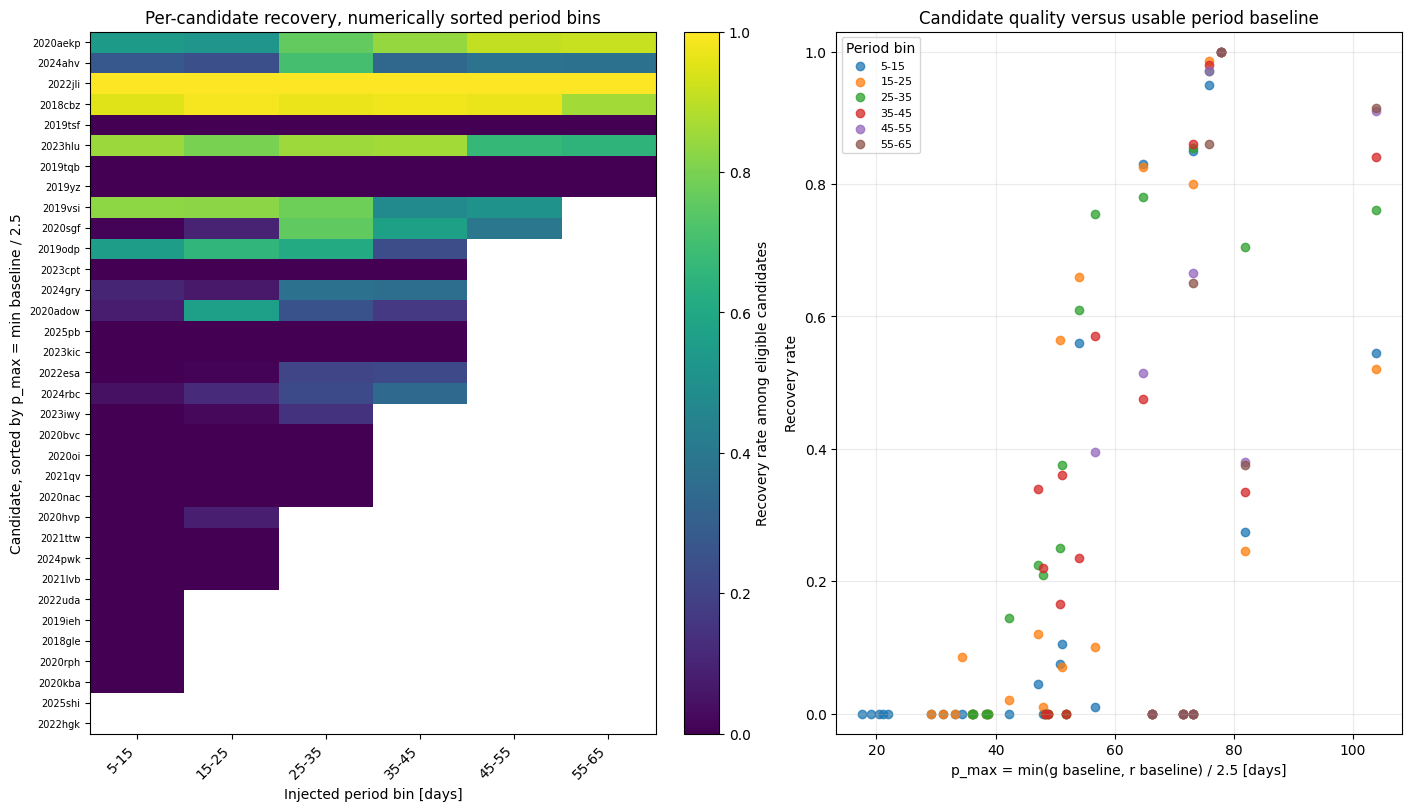

,P_lo,P_hi,period_bin,n_eligible,mean_conditional_recovery,mean_full_sample_recovery
0,5,15,5-15,32,0.163906,0.154265
1,15,25,15-25,27,0.222407,0.176618
2,25,35,25-35,23,0.332174,0.224706
3,35,45,35-45,18,0.354444,0.187647
4,45,55,45-55,10,0.483500,0.142206
5,55,65,55-65,8,0.475000,0.111765


In [22]:
# Replot per-candidate recovery diagnostic with period bins in numeric order
baseline_diag_table = pd.read_csv("baseline_candidate_recovery_diagnostic.csv")

period_order = (
    baseline_diag_table[["P_lo", "P_hi"]]
    .drop_duplicates()
    .sort_values(["P_lo", "P_hi"])
)
period_order["period_bin"] = period_order.apply(
    lambda row: f"{int(row['P_lo'])}-{int(row['P_hi'])}",
    axis=1,
)
period_bin_order = period_order["period_bin"].tolist()

baseline_diag_table["period_bin"] = pd.Categorical(
    baseline_diag_table["period_bin"],
    categories=period_bin_order,
    ordered=True,
)

candidate_order = (
    baseline_diag_table[["name", "p_max"]]
    .drop_duplicates()
    .sort_values("p_max")
    ["name"]
)

baseline_diag_heatmap = (
    baseline_diag_table
    .pivot(index="name", columns="period_bin", values="recovery_rate")
    .reindex(index=candidate_order, columns=period_bin_order)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 8), constrained_layout=True)

im = axes[0].imshow(
    baseline_diag_heatmap.values,
    origin="lower",
    aspect="auto",
    cmap="viridis",
    vmin=0,
    vmax=1,
)
axes[0].set_xticks(np.arange(len(period_bin_order)))
axes[0].set_xticklabels(period_bin_order, rotation=45, ha="right")
axes[0].set_yticks(np.arange(len(baseline_diag_heatmap.index)))
axes[0].set_yticklabels(baseline_diag_heatmap.index, fontsize=7)
axes[0].set_xlabel("Injected period bin [days]")
axes[0].set_ylabel("Candidate, sorted by p_max = min baseline / 2.5")
axes[0].set_title("Per-candidate recovery, numerically sorted period bins")
cbar = fig.colorbar(im, ax=axes[0])
cbar.set_label("Recovery rate among eligible candidates")

period_cmap = plt.get_cmap("tab10")
for i, period_bin in enumerate(period_bin_order):
    group = baseline_diag_table[
        (baseline_diag_table["period_bin"] == period_bin) &
        (baseline_diag_table["eligible"])
    ]
    axes[1].scatter(
        group["p_max"],
        group["recovery_rate"],
        s=36,
        alpha=0.75,
        color=period_cmap(i),
        label=period_bin,
    )

axes[1].set_xlabel("p_max = min(g baseline, r baseline) / 2.5 [days]")
axes[1].set_ylabel("Recovery rate")
axes[1].set_ylim(-0.03, 1.03)
axes[1].set_title("Candidate quality versus usable period baseline")
axes[1].legend(title="Period bin", fontsize=8)
axes[1].grid(alpha=0.25)

plt.show()

summary_sorted = (
    baseline_diag_table
    .groupby(["P_lo", "P_hi", "period_bin"], observed=True)
    .agg(
        n_eligible=("eligible", "sum"),
        mean_conditional_recovery=("recovery_rate", "mean"),
        mean_full_sample_recovery=("recovery_rate_full_sample", "mean"),
    )
    .reset_index()
    .sort_values(["P_lo", "P_hi"])
)

display(summary_sorted)


/var/folders/9v/9mgg2nhs31x_zn1r4181_xym0000gn/T/ipykernel_87385/2083834446.py:47: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(7, 4))


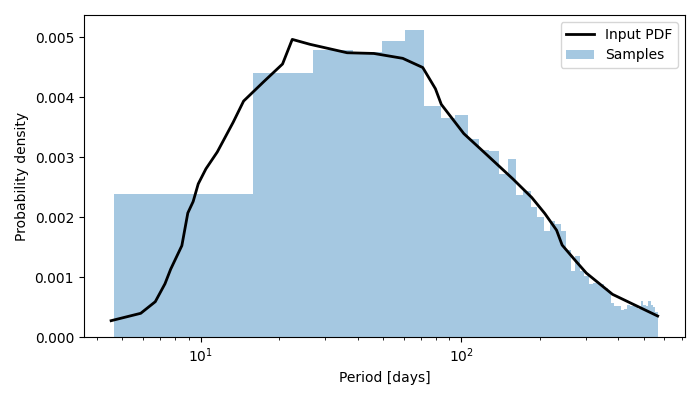

In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

period_dist = pd.read_csv("tables/period_dist.csv")

x = period_dist["x"].to_numpy(dtype=float)   # period
y = period_dist["y"].to_numpy(dtype=float)   # occurrence [%] or relative weight

# Sort just in case the CSV is not ordered
order = np.argsort(x)
x = x[order]
y = y[order]

# Ensure non-negative weights
y = np.clip(y, 0, None)

# Normalize area under the curve to 1
area = np.trapezoid(y, x)
pdf = y / area

# # Build CDF by cumulative trapezoidal integration
dx = np.diff(x)
cdf = np.zeros_like(x)
cdf[1:] = np.cumsum(0.5 * (pdf[1:] + pdf[:-1]) * dx)
cdf = cdf / cdf[-1]

# Inverse-CDF sampler
inverse_cdf = interp1d(
    cdf,
    x,
    bounds_error=False,
    fill_value=(x[0], x[-1]),
)

def sample_periods(n, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    u = rng.uniform(0, 1, size=n)
    return inverse_cdf(u)

# Example
rng = np.random.default_rng(12345)
period_samples = sample_periods(10000, rng=rng)

plt.figure(figsize=(7, 4))
plt.semilogx(x, pdf, color="black", lw=2, label="Input PDF")
plt.hist(period_samples, bins=50, density=True, alpha=0.4, label="Samples")

plt.xlabel("Period [days]")
plt.ylabel("Probability density")
plt.legend()
plt.tight_layout()
plt.show()


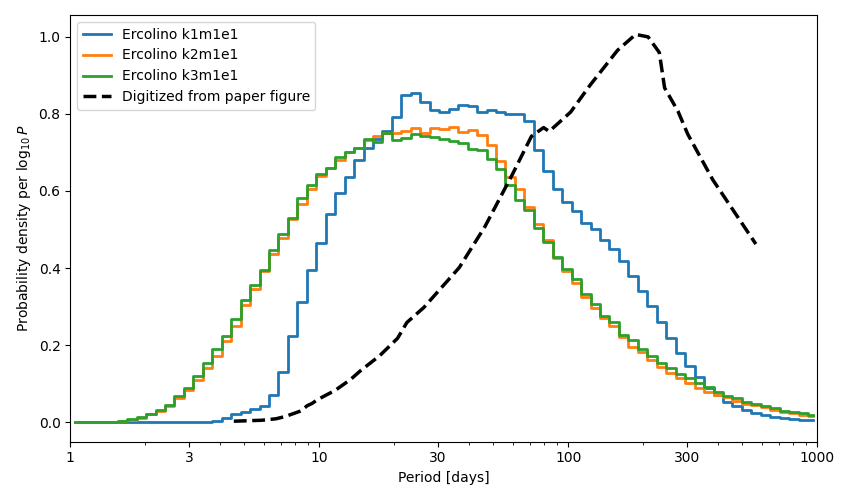

Ercolino k1m1e1: N=2,493,238, sum(pdf)=1.00000261, median=40.31 d, p95=226.71 d, p99=405.87 d
Ercolino k2m1e1: N=1,260,462, sum(pdf)=0.99996014, median=27.01 d, p95=208.49 d, p99=552.83 d
Ercolino k3m1e1: N=879,868, sum(pdf)=1.00002696, median=26.68 d, p95=224.76 d, p99=590.69 d
Digitized: median=132.57 d, p95=472.10 d, p99=547.16 d


In [136]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ERCOLINO_PERIOD_FILES = {
    "k1m1e1": "ercolino_dist/k1m1e1_P_pdf.data",
    "k2m1e1": "ercolino_dist/k2m1e1_P_pdf.data",
    "k3m1e1": "ercolino_dist/k3m1e1_P_pdf.data",
}
MOCK_PERIOD_DIST_PATH = "tables/period_dist.csv"


def load_ercolino_period_distribution(path):
    dist = pd.read_csv(path, sep=r"\s+", comment="#")
    dist = dist[["period_days", "pdf"]].dropna()
    dist = dist[(dist["period_days"] > 0) & (dist["pdf"] > 0)].copy()

    periods = dist["period_days"].to_numpy(dtype=float)
    weights = dist["pdf"].to_numpy(dtype=float)
    weights = weights / weights.sum()
    return periods, weights, dist


def load_mock_period_distribution(path):
    dist = pd.read_csv(path)
    x = dist["x"].to_numpy(dtype=float)
    y = dist["y"].to_numpy(dtype=float)

    order = np.argsort(x)
    x = x[order]
    y = np.clip(y[order], 0, None)

    area = np.trapezoid(y, x)
    if not np.isfinite(area) or area <= 0:
        raise ValueError(f"Invalid mock period PDF normalization area: {area}")
    pdf = y / area

    cdf = np.zeros_like(x)
    cdf[1:] = np.cumsum(0.5 * (pdf[1:] + pdf[:-1]) * np.diff(x))
    cdf = cdf / cdf[-1]
    return x, pdf, cdf


def weighted_quantile(values, weights, quantiles):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    quantiles = np.asarray(quantiles, dtype=float)

    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    cdf = np.cumsum(weights)
    cdf = cdf / cdf[-1]
    return np.interp(quantiles, cdf, values)


def cdf_quantile(x, cdf, quantiles):
    return np.interp(quantiles, cdf, x)


ercolino_period_dists = {}
for label, filepath in ERCOLINO_PERIOD_FILES.items():
    periods, weights, dist = load_ercolino_period_distribution(filepath)
    ercolino_period_dists[label] = {
        "path": filepath,
        "periods": periods,
        "weights": weights,
        "table": dist,
    }

mock_period_days, mock_period_pdf, mock_period_cdf = load_mock_period_distribution(MOCK_PERIOD_DIST_PATH)

# Default real-period sampler: k1m1e1.
real_period_values = ercolino_period_dists["k1m1e1"]["periods"]
real_period_weights = ercolino_period_dists["k1m1e1"]["weights"]


def sample_real_periods(n, rng=None, replace=True, model="k1m1e1"):
    """Sample periods from one Ercolino weighted empirical distribution."""
    if rng is None:
        rng = np.random.default_rng()

    dist = ercolino_period_dists[model]
    return rng.choice(
        dist["periods"],
        size=n,
        replace=replace,
        p=dist["weights"],
    )


log_period_bins = np.linspace(0, 3, 80)  # log10(P/day), i.e. 1-1000 days
log_period_centers = 0.5 * (log_period_bins[:-1] + log_period_bins[1:])
period_centers = 10**log_period_centers

plt.figure(figsize=(8.5, 5.0))
for label, dist in ercolino_period_dists.items():
    log_periods = np.log10(dist["periods"])
    mask = (log_periods >= log_period_bins[0]) & (log_periods <= log_period_bins[-1])
    density_logp, _ = np.histogram(
        log_periods[mask],
        bins=log_period_bins,
        weights=dist["weights"][mask],
        density=True,
    )
    plt.step(
        period_centers,
        density_logp,
        where="mid",
        linewidth=2,
        label=f"Ercolino {label}",
    )

mock_mask = (mock_period_days >= 1) & (mock_period_days <= 1000)
mock_log_period_days = np.log10(mock_period_days[mock_mask])
# If f(P) is density per day, then density per log10(P) is f(P) * P * ln(10).
mock_log_pdf = mock_period_pdf[mock_mask] * mock_period_days[mock_mask] * np.log(10)
mock_log_area = np.trapezoid(mock_log_pdf, mock_log_period_days)
if mock_log_area > 0:
    mock_log_pdf = mock_log_pdf / mock_log_area

plt.plot(
    mock_period_days[mock_mask],
    mock_log_pdf,
    color="black",
    linestyle="--",
    linewidth=2.5,
    label="Digitized from paper figure",
)

plt.xscale("log")
plt.xlim(1, 1000)
plt.xticks([1, 3, 10, 30, 100, 300, 1000], ["1", "3", "10", "30", "100", "300", "1000"])
plt.xlabel("Period [days]")
plt.ylabel(r"Probability density per $\log_{10} P$")
plt.legend()
plt.tight_layout()
plt.show()

for label, dist in ercolino_period_dists.items():
    median, p95, p99 = weighted_quantile(
        dist["periods"],
        dist["weights"],
        [0.50, 0.95, 0.99],
    )
    raw_pdf_sum = dist["table"]["pdf"].sum()
    print(
        f"Ercolino {label}: N={len(dist['periods']):,}, "
        f"sum(pdf)={raw_pdf_sum:.8f}, "
        f"median={median:.2f} d, p95={p95:.2f} d, p99={p99:.2f} d"
    )

mock_median, mock_p95, mock_p99 = cdf_quantile(
    mock_period_days,
    mock_period_cdf,
    [0.50, 0.95, 0.99],
)
print(
    f"Digitized: median={mock_median:.2f} d, "
    f"p95={mock_p95:.2f} d, p99={mock_p99:.2f} d"
)


Population sizes:   0%|          | 0/31 [00:00<?, ?it/s]

,X,MeanSumPij,MedianSumPij,P_sum_gt_3,PercentileOf3
0,3,0.584540,0.555991,0.000,1.000
1,4,0.815053,0.778038,0.000,1.000
2,5,0.969170,0.953528,0.000,1.000
3,6,1.149403,1.116287,0.002,0.998
4,7,1.366438,1.352289,0.007,0.993
5,8,1.539141,1.512374,0.011,0.989
6,9,1.733667,1.698210,0.035,0.965
7,10,1.895647,1.889546,0.065,0.935
8,11,2.125886,2.120940,0.124,0.876
9,12,2.319254,2.333739,0.188,0.812


First X with P(sum Pij > 3) >= 95%: X = 25


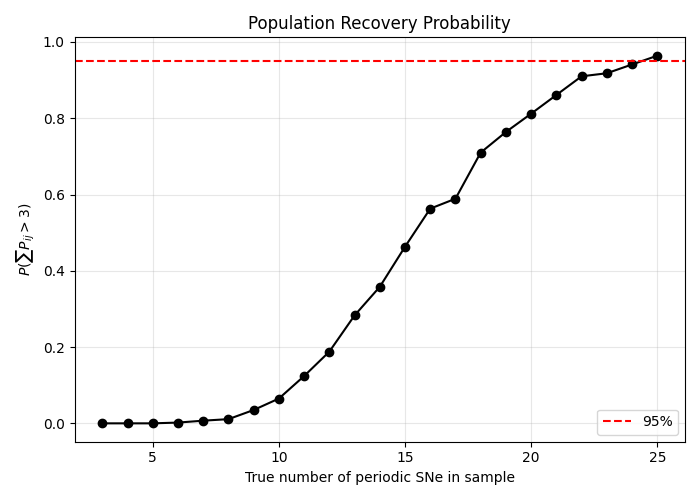

In [148]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

N_POP_DRAWS = 1000
X_VALUES = np.arange(3, 34)
TARGET_DETECTIONS = 3
PERIOD_MIN = 5
PERIOD_MAX = 250
AMP_MIN = 0
AMP_MAX = 0.2

rng = np.random.default_rng(54321)


def lookup_Pij(period, amplitude, Pij_table):
    row = Pij_table[
        (Pij_table["P_lo"] <= period) &
        (period < Pij_table["P_hi"]) &
        (Pij_table["A_lo"] <= amplitude) &
        (amplitude < Pij_table["A_hi"])
    ]

    if len(row) == 0:
        return 0.0

    return float(row.iloc[0]["Pij"])


population_rows = []
sum_draws_by_X = {}

for X in tqdm(X_VALUES, desc="Population sizes", dynamic_ncols=True):
    sums = []

    for _ in range(N_POP_DRAWS):
        periods = sample_real_periods(X, rng=rng, model="k1m1e1")
        amplitudes = rng.uniform(AMP_MIN, AMP_MAX, size=X)

        pij_values = [
            lookup_Pij(period, amplitude, Pij_table)
            for period, amplitude in zip(periods, amplitudes)
        ]

        sums.append(np.sum(pij_values))

    sums = np.array(sums)
    sum_draws_by_X[X] = sums

    prob_gt_3 = np.mean(sums > TARGET_DETECTIONS)
    percentile_of_3 = np.mean(sums <= TARGET_DETECTIONS)

    population_rows.append({
        "X": X,
        "MeanSumPij": np.mean(sums),
        "MedianSumPij": np.median(sums),
        "P_sum_gt_3": prob_gt_3,
        "PercentileOf3": percentile_of_3,
    })

    if prob_gt_3 >= 0.95:
        break

population_table = pd.DataFrame(population_rows)
population_table.to_csv("population_periodic_SN_simulation.csv", index=False)

display(population_table)

x_95 = population_table.loc[
    population_table["P_sum_gt_3"] >= 0.95,
    "X"
]

if len(x_95) > 0:
    print(f"First X with P(sum Pij > 3) >= 95%: X = {int(x_95.iloc[0])}")
else:
    print("No X in the tested range reached P(sum Pij > 3) >= 95%")

plt.figure(figsize=(7, 5))
plt.plot(
    population_table["X"],
    population_table["P_sum_gt_3"],
    marker="o",
    color="black",
)

plt.axhline(0.95, color="red", ls="--", label="95%")
plt.xlabel("True number of periodic SNe in sample")
plt.ylabel(r"$P(\sum P_{ij} > 3)$")
plt.title("Population Recovery Probability")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Population sizes:   0%|          | 0/31 [00:00<?, ?it/s]

,X,MeanSumPij,MedianSumPij,P_sum_gt_3,PercentileOf3
0,3,0.498607,0.480016,0.000,1.000
1,4,0.682044,0.645340,0.000,1.000
2,5,0.823537,0.782898,0.000,1.000
3,6,1.004724,0.973626,0.000,1.000
4,7,1.174987,1.158763,0.002,0.998
5,8,1.337759,1.291855,0.002,0.998
6,9,1.466181,1.445586,0.007,0.993
7,10,1.650054,1.618342,0.019,0.981
8,11,1.804031,1.784975,0.026,0.974
9,12,2.026679,2.003676,0.091,0.909


First X with P(sum Pij > 3) >= 95%: X = 29


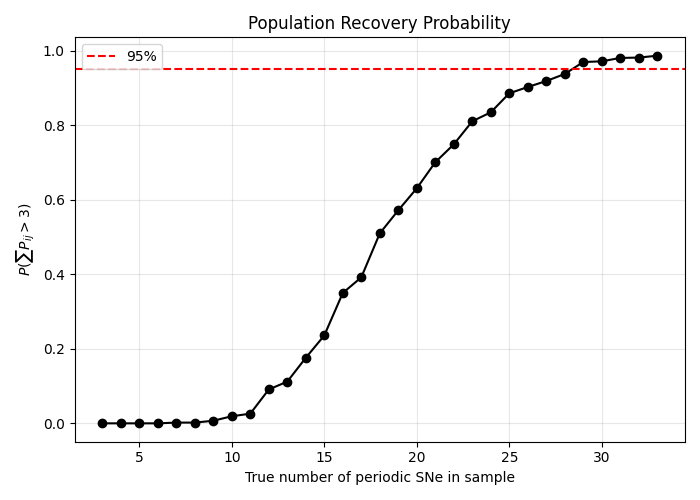

In [128]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

N_POP_DRAWS = 1000
X_VALUES = np.arange(3, 34)
TARGET_DETECTIONS = 3
PERIOD_MIN = 5
PERIOD_MAX = 250
AMP_MIN = 0
AMP_MAX = 0.2

rng = np.random.default_rng(54321)


def lookup_Pij(period, amplitude, Pij_table):
    row = Pij_table[
        (Pij_table["P_lo"] <= period) &
        (period < Pij_table["P_hi"]) &
        (Pij_table["A_lo"] <= amplitude) &
        (amplitude < Pij_table["A_hi"])
    ]

    if len(row) == 0:
        return 0.0

    return float(row.iloc[0]["Pij"])


population_rows = []
sum_draws_by_X = {}

for X in tqdm(X_VALUES, desc="Population sizes", dynamic_ncols=True):
    sums = []

    for _ in range(N_POP_DRAWS):
        periods = sample_real_periods(X, rng=rng, model="k2m1e1")
        amplitudes = rng.uniform(AMP_MIN, AMP_MAX, size=X)

        pij_values = [
            lookup_Pij(period, amplitude, Pij_table)
            for period, amplitude in zip(periods, amplitudes)
        ]

        sums.append(np.sum(pij_values))

    sums = np.array(sums)
    sum_draws_by_X[X] = sums

    prob_gt_3 = np.mean(sums > TARGET_DETECTIONS)
    percentile_of_3 = np.mean(sums <= TARGET_DETECTIONS)

    population_rows.append({
        "X": X,
        "MeanSumPij": np.mean(sums),
        "MedianSumPij": np.median(sums),
        "P_sum_gt_3": prob_gt_3,
        "PercentileOf3": percentile_of_3,
    })

population_table = pd.DataFrame(population_rows)
population_table.to_csv("population_periodic_SN_simulation.csv", index=False)

display(population_table)

x_95 = population_table.loc[
    population_table["P_sum_gt_3"] >= 0.95,
    "X"
]

if len(x_95) > 0:
    print(f"First X with P(sum Pij > 3) >= 95%: X = {int(x_95.iloc[0])}")
else:
    print("No X in the tested range reached P(sum Pij > 3) >= 95%")

plt.figure(figsize=(7, 5))
plt.plot(
    population_table["X"],
    population_table["P_sum_gt_3"],
    marker="o",
    color="black",
)

plt.axhline(0.95, color="red", ls="--", label="95%")
plt.xlabel("True number of periodic SNe in sample")
plt.ylabel(r"$P(\sum P_{ij} > 3)$")
plt.title("Population Recovery Probability")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [25]:
from collections import defaultdict
bands_per_sn = defaultdict(set)
for entry in candidate_library:
    bands_per_sn[entry["name"]].add(entry["fid"])
dual_band_sne = {
    name for name, bands in bands_per_sn.items()
    if {1, 2}.issubset(bands)
}
# list periods for dual-band SNe (using poly3 results), sorted longest -> shortest
periods = []
for name in sorted(dual_band_sne):
    if name in grouped_results.get("poly3", {}):
        prs = [res["time_baseline"] for res in grouped_results["poly3"][name]]
        if prs:
            periods.append((name, float(min(prs)/2.5)))  # conservative: use the longer period

periods_sorted = sorted(periods, key=lambda x: x[1], reverse=True)
for name, p in periods_sorted:
    print(f"{name}: {p:.3f} d")


2020aekp: 103.834 d
2024ahv: 81.871 d
2022jli: 77.864 d
2018cbz: 75.865 d
2019tsf: 73.077 d
2023hlu: 73.066 d
2019tqb: 71.499 d
2019yz: 66.259 d
2019vsi: 64.683 d
2020sgf: 56.717 d
2019odp: 53.962 d
2023cpt: 51.884 d
2024gry: 51.084 d
2020adow: 50.758 d
2025pb: 48.717 d
2023kic: 48.326 d
2022esa: 47.892 d
2024rbc: 47.101 d
2023iwy: 42.286 d
2020bvc: 38.690 d
2020oi: 38.314 d
2021qv: 36.285 d
2020nac: 35.969 d
2020hvp: 34.324 d
2021ttw: 33.124 d
2024pwk: 31.166 d
2021lvb: 29.121 d
2022uda: 21.961 d
2019ieh: 21.144 d
2018gle: 20.367 d
2020rph: 19.169 d
2020kba: 17.576 d
2025shi: 14.006 d
2022hgk: 9.569 d


## Generating Tables


In [106]:
# Generate LaTeX format for Table 1 — poly3 only

double_hits, updated_grouped = find_dual_band_hits(grouped_results, candidate_library)
method = "poly3"

print(r"\begin{table*}")
print(r"\centering")
print(r"\begin{tabular}{lcccccc}")
print(r"\hline")
print(r"SN & $P_g$ & $A_g$ & $p_g$ & $P_r$ & $A_r$ & $p_r$ \\")
print(r"& [Days] & [mag] & & [Days] & [mag] & \\")
print(r"\hline")

def format_pval(pval):
    if pval > 0:
        exponent = int(np.floor(np.log10(pval)))
        mantissa = pval / 10**exponent
        return rf"${mantissa:.0f}\cdot 10^{{{exponent}}}$"
    else:
        return r"$<10^{-16}$"

def format_period(res):
    P = res["best_period"]
    lo = P-res["period_lo"]
    hi = res["period_hi"]-P
    return rf"${P:.1f}^{{+{hi:.1f}}}_{{-{lo:.1f}}}$"

for name in sorted(double_hits.get(method, [])):

    band_results = updated_grouped[method][name]

    g_res = next(r for r in band_results if r["fid"] == 1)
    r_res = next(r for r in band_results if r["fid"] == 2)

    pval_g = format_pval(g_res["p_value_single_freq"])
    pval_r = format_pval(r_res["p_value_single_freq"])

    Pg = format_period(g_res)
    Pr = format_period(r_res)

    print(f"{name} & "
          f"{Pg} & "
          f"{g_res['best_amplitude']:.2f} & "
          f"{pval_g} & "
          f"{Pr} & "
          f"{r_res['best_amplitude']:.2f} & "
          f"{pval_r} \\\\")
    
print(r"\hline")
print(r"\end{tabular}")
print(r"\caption{Dual-band periodic detections identified using a third-degree polynomial baseline. "
      r"Periods, amplitudes, and single-frequency $p$-values are listed for both bands.}")
print(r"\label{tab:double_hits_poly3}")
print(r"\end{table*}")


\begin{table*}
\centering
\begin{tabular}{lcccccc}
\hline
SN & $P_g$ & $A_g$ & $p_g$ & $P_r$ & $A_r$ & $p_r$ \\
& [Days] & [mag] & & [Days] & [mag] & \\
\hline
2020sgf & $30.2^{+0.3}_{-1.2}$ & 0.20 & $6\cdot 10^{-10}$ & $35.9^{+2.0}_{-1.5}$ & 0.12 & $2\cdot 10^{-9}$ \\
2022esa & $34.2^{+2.2}_{-3.5}$ & 0.14 & $10\cdot 10^{-5}$ & $34.2^{+2.7}_{-1.8}$ & 0.11 & $5\cdot 10^{-5}$ \\
2022jli & $12.6^{+0.1}_{-0.3}$ & 0.07 & $2\cdot 10^{-12}$ & $12.4^{+0.1}_{-0.3}$ & 0.04 & $1\cdot 10^{-5}$ \\
\hline
\end{tabular}
\caption{Dual-band periodic detections identified using a third-degree polynomial baseline. Periods, amplitudes, and single-frequency $p$-values are listed for both bands.}
\label{tab:double_hits_poly3}
\end{table*}


In [ ]:
''' generate LaTeX for Table 2 only poly3'''

double_hits, updated_grouped = find_dual_band_hits(grouped_results, candidate_library)
selected_names = double_hits.get("poly3", [])

print(r"\begin{table*}")
print(r"\centering")
print(r"\begin{tabular}{lcccccccc}")
print(r"\hline")
print(r"SN & Band & $P$ & $A$ & MDA & $p$-value & $\Delta\chi^2$ & $\chi^2_{\text{poly}}$ & $\chi^2_{\text{full}}$ \\")
print(r"& & [Days] & [mag] & [mag] & & & & \\")
print(r"\hline")

def format_pval(pval):
    if pval > 0:
        exponent = int(np.floor(np.log10(pval)))
        mantissa = pval / 10**exponent
        return rf"${mantissa:.0f}\cdot 10^{{{exponent}}}$"
    else:
        return r"$<10^{-16}$"

for name in selected_names:

    total_rows = 2
    first_row = True

    if name not in updated_grouped.get("poly3", {}):
        continue

    band_results = updated_grouped["poly3"][name]

    for res in band_results:

        fid = res["fid"]
        band = "g" if fid == 1 else "r"

        period = res["best_period"]
        amplitude = res["best_amplitude"]
        pval = format_pval(res["p_value_single_freq"])
        dchi2 = res["delta_chi2"]
        chi2_poly = res["chi2_poly"]
        chi2_full = chi2_poly - dchi2
        mda = res["mda"]

        if first_row:
            print(rf"\multirow{{{total_rows}}}{{*}}{{{name}}} "
                    f"& {band} & "
                    f"{period:.1f} & "
                    f"{amplitude:.2f} & "
                    f"{mda:.2f} & "
                    f"{pval} & "
                    f"{dchi2:.2f} & "
                    f"{chi2_poly:.2f} & "
                    f"{chi2_full:.2f} \\\\")
            first_row = False
        else:
            print(f"& {band} & "
                    f"{period:.1f} & "
                    f"{amplitude:.2f} & "
                    f"{mda:.2f} & "
                    f"{pval} & "
                    f"{dchi2:.2f} & "
                    f"{chi2_poly:.2f} & "
                    f"{chi2_full:.2f} \\\\")

    print(r"\hline")

print(r"\end{tabular}")
print(r"\caption{Band-level periodicity diagnostics for the dual-band detections. For each photometric band, we report the best-fit period, amplitude, minimal detectable amplitude, single-frequency $p$-value, $\Delta\chi^2$ and the $\chi^2$ values for both the polynomial-only and full (polynomial+sinusoid) models." \
" By construction, $\chi^2 \approx \nu$ (see \ref{sec:model_fitting}).}")
print(r"\label{tab:band_level}")
print(r"\end{table*}")


\begin{table*}
\centering
\begin{tabular}{lcccccccc}
\hline
SN & Band & $P$ & $A$ & MDA & $p$-value & $\Delta\chi^2$ & $\chi^2_{\text{poly}}$ & $\chi^2_{\text{full}}$ \\
& & [Days] & [mag] & [mag] & & & & \\
\hline
\multirow{2}{*}{2020sgf} & g & 30.2 & 0.20 & 0.02 & $6\cdot 10^{-10}$ & 42.46 & 78.00 & 35.54 \\
& r & 35.9 & 0.12 & 0.01 & $2\cdot 10^{-9}$ & 39.77 & 96.00 & 56.23 \\
\hline
\multirow{2}{*}{2022jli} & g & 12.6 & 0.07 & 0.01 & $2\cdot 10^{-12}$ & 53.85 & 91.00 & 37.15 \\
& r & 12.4 & 0.04 & 0.01 & $1\cdot 10^{-5}$ & 22.55 & 82.00 & 59.45 \\
\hline
\multirow{2}{*}{2022esa} & r & 34.2 & 0.11 & 0.02 & $5\cdot 10^{-5}$ & 19.95 & 30.00 & 10.05 \\
& g & 34.2 & 0.14 & 0.03 & $10\cdot 10^{-5}$ & 18.48 & 29.00 & 10.52 \\
\hline
\end{tabular}
\caption{Band-level periodicity diagnostics for the dual-band detections. For each photometric band, we report the best-fit period, amplitude, minimal detectable amplitude, single-frequency $p$-value, $\Delta\chi^2$ and the $\chi^2$ values for bo

In [ ]:
''' generate LaTeX for Table in Appendix A'''

selected_names = ["2022jli", "2022esa", "2020sgf", "2019tsf"]
methods = ["poly3", "poly4", "poly5", "poly6"]

print(r"\begin{table*}")
print(r"\centering")
print(r"\begin{tabular}{lccccccc}")
print(r"\hline")
print(r"SN & Band & Method & $P$ & $A$ & MDA & $p$-value & $\Delta\chi^2$ \\")
print(r"& & & [Days] & [mag] & [mag] & & \\")
print(r"\hline")

def format_pval(pval):
    if pval > 0:
        exponent = int(np.floor(np.log10(pval)))
        mantissa = pval / 10**exponent
        return rf"${mantissa:.0f}\cdot 10^{{{exponent}}}$"
    else:
        return r"$<10^{-16}$"

for name in selected_names:

    total_rows = 2 * len(methods)  # 2 bands × 4 methods = 8 rows
    first_row = True

    for method in methods:

        if name not in grouped_results.get(method, {}):
            continue

        band_results = grouped_results[method][name]

        for res in band_results:

            fid = res["fid"]
            band = "g" if fid == 1 else "r"

            period = res["best_period"]
            amplitude = res["best_amplitude"]
            pval = format_pval(res["p_value_single_freq"])
            dchi2 = res["delta_chi2"]
            mda = res["mda"]

            if first_row:
                print(rf"\multirow{{{total_rows}}}{{*}}{{{name}}} "
                      f"& {band} & {method} & "
                      f"{period:.1f} & "
                      f"{amplitude:.2f} & "
                      f"{mda:.2f} & "
                      f"{pval} & "
                      f"{dchi2:.2f} \\\\")
                first_row = False
            else:
                print(f"& {band} & {method} & "
                      f"{period:.1f} & "
                      f"{amplitude:.2f} & "
                      f"{mda:.2f} & "
                      f"{pval} & "
                      f"{dchi2:.2f} \\\\")

    print(r"\hline")

print(r"\end{tabular}")
print(r"\caption{Band-level periodicity diagnostics for dual-band detections, and SN~2019tsf mentioned in \ref{app:2019tsf} For each polynomial baseline (poly3-poly6) and photometric band, we report the best-fit period, amplitude, minimal detectable amplitude, single-frequency $p$-value, and $\Delta\chi^2$. " \
r"The periods per band in this Table were extracted using the global peak in $\Delta \chi^2$, unlike the harmonics-avoiding technique used for the rest of the pipeline (\ref{sec:model_fitting}) and provided here for the purpose of diagnostics.}")
print(r"\label{tab:all_baselines}")
print(r"\end{table*}")


\begin{table*}
\centering
\begin{tabular}{lccccccc}
\hline
SN & Band & Method & $P$ & $A$ & MDA & $p$-value & $\Delta\chi^2$ \\
& & & [Days] & [mag] & [mag] & & \\
\hline
\multirow{8}{*}{2022jli} & g & poly3 & 12.6 & 0.07 & 0.01 & $2\cdot 10^{-12}$ & 53.85 \\
& r & poly3 & 12.4 & 0.04 & 0.01 & $1\cdot 10^{-5}$ & 22.55 \\
& g & poly4 & 12.6 & 0.07 & 0.01 & $1\cdot 10^{-13}$ & 59.27 \\
& r & poly4 & 12.4 & 0.04 & 0.01 & $6\cdot 10^{-7}$ & 28.62 \\
& g & poly5 & 12.6 & 0.07 & 0.01 & $2\cdot 10^{-13}$ & 58.59 \\
& r & poly5 & 12.4 & 0.04 & 0.01 & $8\cdot 10^{-7}$ & 28.02 \\
& g & poly6 & 12.6 & 0.07 & 0.01 & $3\cdot 10^{-13}$ & 57.95 \\
& r & poly6 & 12.4 & 0.04 & 0.00 & $6\cdot 10^{-7}$ & 28.78 \\
\hline
\multirow{8}{*}{2022esa} & g & poly3 & 34.2 & 0.14 & 0.03 & $10\cdot 10^{-5}$ & 18.48 \\
& r & poly3 & 34.2 & 0.11 & 0.02 & $5\cdot 10^{-5}$ & 19.95 \\
& g & poly4 & 36.3 & 0.15 & 0.02 & $5\cdot 10^{-5}$ & 20.01 \\
& r & poly4 & 36.3 & 0.12 & 0.01 & $2\cdot 10^{-5}$ & 21.40 \\
& g & poly5

### Lightcurve from LAST


/var/folders/9v/9mgg2nhs31x_zn1r4181_xym0000gn/T/ipykernel_25518/253558399.py:10: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  df['jd'] = Time(ts.dt.tz_convert('UTC').dt.to_pydatetime(), scale='utc').jd % 1e4


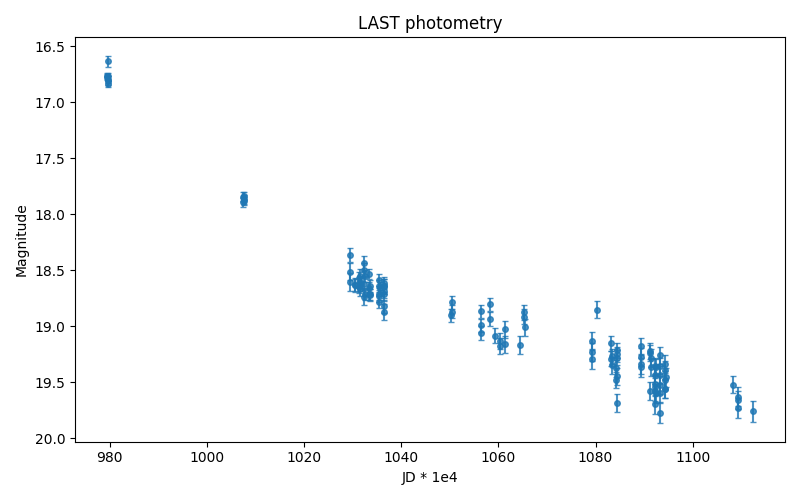

In [82]:
%matplotlib widget
import matplotlib.pyplot as plt
path = "/Users/asaf/Downloads/updated-data-for-2025abdd-from-cast.csv"

df = pd.read_csv(path)

df = df[df['source_name'] == 'LAST'].copy()
ts = pd.to_datetime(df['timestamp'], utc=True, errors='coerce')
df = df[ts.notna()].copy()
df['jd'] = Time(ts.dt.tz_convert('UTC').dt.to_pydatetime(), scale='utc').jd % 1e4
df['mag'] = pd.to_numeric(df['magnitude'].astype(str).str.lstrip('>').str.strip(), errors='coerce')
df['error'] = pd.to_numeric(df['error'].astype(str).str.strip(), errors='coerce')
mask = df['mag'].notna() & df['error'].notna()

plt.figure(figsize=(8, 5))
plt.errorbar(
    df.loc[mask, 'jd'],
    df.loc[mask, 'mag'],
    yerr=df.loc[mask, 'error'],
    fmt='o',
    ms=4,
    capsize=2,
    alpha=0.8
)
plt.gca().invert_yaxis()
plt.xlabel("JD * 1e4")
plt.ylabel("Magnitude")
plt.title("LAST photometry")
plt.tight_layout()
plt.show()
